#  Health & Fitness Data Analytics Project
### By ~ Team 404

---

**Welcome!** In This notebook you will get a step-by-step guide to analyzing a real-world health and fitness dataset.

**Team Members**
- Abhijeet Rogye [AF0357190]
- Arya Kurup [AF0357211]
- Viraj Tamhanekar [AF05130141]

**What is this dataset about?**
- It contains health & fitness data from **3,000 users** tracked over **30 days**
- Data includes: steps, heart rate, sleep, blood pressure, glucose levels, calories, and more
- Think of it as data from a smartwatch (like Google Fit) combined with medical check-ups

**What will we do?**
1.  **Load the data** — Read the CSV file into Python
2.  **Clean the data** — Fix errors, missing values, and inconsistencies
3.  **Explore the data (EDA)** — Find patterns using charts and statistics
4.  **Generate insights** — Understand what the data tells us
5.  **Make recommendations** — Suggest actions based on findings
6.  **Bonus** — Feature engineering and predictive modeling


---
## 1️ Step 1: Import Required Libraries

**What are libraries?**
Think of libraries as **toolboxes**. Instead of building everything from scratch, we use pre-built tools:

| Library | What it does | Real-world analogy |
|---------|-------------|--------------------|
| `pandas` | Handles data in table format | Like Excel, but more powerful |
| `numpy` | Does math operations | Like a scientific calculator |
| `matplotlib` | Creates basic charts | Like drawing graphs on paper |
| `seaborn` | Creates beautiful charts | Like matplotlib but prettier |
| `warnings` | Hides unnecessary warning messages | Like muting notifications |

**Why do we need them?**
Without these libraries, we'd have to write thousands of lines of code to do simple things like reading a file or drawing a chart.

In [4]:
# ============================================================
# STEP 1: Import all the libraries (toolboxes) we need
# ============================================================

import pandas as pd                # For reading and manipulating data (like Excel)
import numpy as np                 # For mathematical calculations
import matplotlib.pyplot as plt    # For creating basic charts and graphs
import seaborn as sns              # For creating beautiful statistical charts
import warnings                    # To hide unnecessary warning messages

# Settings to make our charts look clean and professional
warnings.filterwarnings('ignore')           # Hide warnings so output stays clean
sns.set_style('whitegrid')                  # Use a clean white background for charts
plt.rcParams['figure.figsize'] = (12, 6)    # Set default chart size (width=12, height=6)
plt.rcParams['font.size'] = 12              # Set readable font size
plt.rcParams['axes.titlesize'] = 14         # Titles slightly bigger

# This line makes charts appear directly in the notebook
%matplotlib inline

print('✅ All libraries imported successfully! We are ready to go.')

✅ All libraries imported successfully! We are ready to go.


---
## Step 2: Load the Dataset

**What does "loading" mean?**
Our data is stored in a CSV file (Comma-Separated Values — like a spreadsheet saved as text). We need to bring it into Python so we can work with it.

**What is a DataFrame?**
A DataFrame is Python's version of a spreadsheet — data organized in rows and columns.

In [5]:
# ============================================================
# STEP 2: Load the CSV file into a DataFrame
# ============================================================

# pd.read_csv() reads the CSV file and converts it into a table (DataFrame)
df = pd.read_csv('hamon_googlefit_medical_realistic.csv')

print('✅ Dataset loaded successfully!')
print(f'📏 The dataset has {df.shape[0]:,} rows and {df.shape[1]} columns')
print(f'👥 That means {df.shape[0]:,} daily records across {df["user_id"].nunique():,} unique users')

✅ Dataset loaded successfully!
📏 The dataset has 90,000 rows and 37 columns
👥 That means 90,000 daily records across 3,000 unique users


### 2.1 Preview the Data

Let's peek at the data to see what it looks like. We use several commands:

| Command | What it shows |
|---------|---------------|
| `df.head()` | First 5 rows (top of the table) |
| `df.tail()` | Last 5 rows (bottom of the table) |
| `df.shape` | How many rows and columns |
| `df.columns` | Names of all columns |
| `df.info()` | Data types and missing values summary |
| `df.describe()` | Statistical summary (mean, min, max, etc.) |

In [6]:
# Show the FIRST 5 rows — this gives us a quick look at the data
print('📋 First 5 rows of the dataset:')
print('=' * 50)
df.head()

📋 First 5 rows of the dataset:


,user_id,age,sex,bmi,smoking_status,family_history_cvd,fitness_level,height_m,weight_kg,date,...,body_temp_c,sleep_hours,sleep_efficiency,fatigue_score,calories_consumed,water_intake_l,sleep_data_available,bp_measured,glucose_measured,cardiometabolic_risk_state
0,1,23,1,30.753735,0,1,1,1.525007,71.532157,2024-01-01,...,36.7,7.58540,0.93389,4,2246,2.6,True,True,False,2
1,1,23,1,30.753735,0,1,1,1.525007,71.499318,2024-01-02,...,36.4,NaN,NaN,3,2497,2.3,False,False,False,2
2,1,23,1,30.753735,0,1,1,1.525007,71.507641,2024-01-03,...,36.7,7.01264,0.91370,5,2648,1.8,True,False,True,2
3,1,23,1,30.753735,0,1,1,1.525007,71.470106,2024-01-04,...,36.6,NaN,NaN,3,2923,2.1,False,False,True,2
4,1,23,1,30.753735,0,1,1,1.525007,71.475484,2024-01-05,...,36.3,NaN,NaN,4,2372,2.8,False,True,False,2


In [7]:
# Show the LAST 5 rows — useful to check if data ends properly
print('📋 Last 5 rows of the dataset:')
print('=' * 50)
df.tail()

📋 Last 5 rows of the dataset:


,user_id,age,sex,bmi,smoking_status,family_history_cvd,fitness_level,height_m,weight_kg,date,...,body_temp_c,sleep_hours,sleep_efficiency,fatigue_score,calories_consumed,water_intake_l,sleep_data_available,bp_measured,glucose_measured,cardiometabolic_risk_state
89995,3000,59,0,24.901448,0,1,1,1.780008,78.761802,2024-01-26,...,36.3,6.459109,0.911111,3,2601,1.9,True,False,False,2
89996,3000,59,0,24.901448,0,1,1,1.780008,78.774490,2024-01-27,...,36.6,7.937834,0.907769,2,2851,2.0,True,True,False,2
89997,3000,59,0,24.901448,0,1,1,1.780008,78.822934,2024-01-28,...,37.0,9.239769,0.852598,2,2254,1.2,True,True,False,1
89998,3000,59,0,24.901448,0,1,1,1.780008,78.834722,2024-01-29,...,36.4,NaN,NaN,2,2789,2.1,False,True,False,1
89999,3000,59,0,24.901448,0,1,1,1.780008,78.871773,2024-01-30,...,36.8,7.310308,0.882777,2,2404,2.2,True,True,False,2


In [8]:
# Show ALL column names — so we know what data we have
print('📊 All columns in the dataset:')
print('=' * 50)
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}')
print(f'\n📏 Total: {len(df.columns)} columns')

📊 All columns in the dataset:
   1. user_id
   2. age
   3. sex
   4. bmi
   5. smoking_status
   6. family_history_cvd
   7. fitness_level
   8. height_m
   9. weight_kg
  10. date
  11. day_index
  12. activity_type
  13. steps
  14. heart_points
  15. move_minutes
  16. calories_burned
  17. distance_km
  18. step_cadence
  19. cycling_power_watts
  20. avg_heart_rate
  21. resting_hr
  22. hrv
  23. bp_systolic
  24. bp_diastolic
  25. fasting_glucose
  26. postprandial_glucose
  27. spo2
  28. body_temp_c
  29. sleep_hours
  30. sleep_efficiency
  31. fatigue_score
  32. calories_consumed
  33. water_intake_l
  34. sleep_data_available
  35. bp_measured
  36. glucose_measured
  37. cardiometabolic_risk_state

📏 Total: 37 columns


In [9]:
# df.info() — shows data type of each column and how many non-null values
# This helps us spot missing data quickly
print('ℹ️ Dataset Information:')
print('=' * 50)
df.info()

ℹ️ Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     90000 non-null  int64  
 1   age                         90000 non-null  int64  
 2   sex                         90000 non-null  int64  
 3   bmi                         90000 non-null  float64
 4   smoking_status              90000 non-null  int64  
 5   family_history_cvd          90000 non-null  int64  
 6   fitness_level               90000 non-null  int64  
 7   height_m                    90000 non-null  float64
 8   weight_kg                   90000 non-null  float64
 9   date                        90000 non-null  object 
 10  day_index                   90000 non-null  int64  
 11  activity_type               90000 non-null  object 
 12  steps                       90000 non-null  int64  
 13  heart_p

In [10]:
# df.describe() — gives us statistics: count, mean, std, min, 25%, 50%, 75%, max
# This tells us the "spread" of our numerical data
print('📈 Statistical Summary of Numerical Columns:')
print('=' * 50)
df.describe().round(2)

📈 Statistical Summary of Numerical Columns:


,user_id,age,sex,bmi,smoking_status,family_history_cvd,fitness_level,height_m,weight_kg,day_index,...,fasting_glucose,postprandial_glucose,spo2,body_temp_c,sleep_hours,sleep_efficiency,fatigue_score,calories_consumed,water_intake_l,cardiometabolic_risk_state
count,90000.00,90000.00,90000.0,90000.00,90000.0,90000.00,90000.00,90000.00,90000.00,90000.00,...,22314.00,22314.00,90000.00,90000.00,67540.00,67540.00,90000.00,90000.00,90000.0,90000.00
mean,1500.50,48.57,0.5,26.13,0.2,0.30,0.80,1.70,76.16,15.50,...,103.41,140.38,95.46,36.65,7.02,0.85,4.12,2461.53,2.3,1.94
std,866.03,17.96,0.5,4.34,0.4,0.46,0.74,0.10,15.52,8.66,...,14.17,19.29,1.17,0.27,1.20,0.09,2.47,302.44,0.6,0.88
min,1.00,18.00,0.0,18.00,0.0,0.00,0.00,1.45,45.00,1.00,...,70.00,86.00,91.00,35.80,3.00,0.50,0.00,1200.00,0.5,0.00
25%,750.75,33.00,0.0,22.99,0.0,0.00,0.00,1.64,64.91,8.00,...,94.00,127.00,95.00,36.50,6.53,0.82,2.00,2257.00,1.9,1.00
50%,1500.50,48.00,0.0,26.08,0.0,0.00,1.00,1.70,75.11,15.50,...,102.00,139.00,95.00,36.60,7.18,0.87,4.00,2463.00,2.3,2.00
75%,2250.25,64.00,1.0,28.96,0.0,1.00,1.00,1.77,86.15,23.00,...,110.00,153.00,96.00,36.80,7.77,0.91,5.00,2667.00,2.7,2.00
max,3000.00,79.00,1.0,41.54,1.0,1.00,2.00,2.00,134.11,30.00,...,182.00,226.00,100.00,38.30,10.00,0.98,10.00,3840.00,5.0,4.00


###  2.2 Understanding What Each Column Means

Here's a plain-English explanation of every column in our dataset:

| Column | What it Means | Example |
|--------|--------------|----------|
| `user_id` | Unique ID for each person | 1, 2, 3... |
| `age` | Person's age in years | 23, 48, 67 |
| `sex` | Gender (1 = Male, 0 = Female) | 0 or 1 |
| `bmi` | Body Mass Index (weight vs height ratio) | 22.5, 30.7 |
| `smoking_status` | Does the person smoke? (1 = Yes, 0 = No) | 0 or 1 |
| `family_history_cvd` | Family history of heart disease? (1 = Yes) | 0 or 1 |
| `fitness_level` | How fit the person is (0=Low, 1=Medium, 2=High) | 0, 1, 2 |
| `height_m` | Height in meters | 1.52, 1.80 |
| `weight_kg` | Weight in kilograms | 71.5, 86.1 |
| `date` | Date of the record | 2024-01-01 |
| `day_index` | Day number (1-30) | 1, 15, 30 |
| `activity_type` | What exercise they did | Walking, Running, Yoga |
| `steps` | Steps walked that day | 6,714 |
| `heart_points` | Google Fit heart points earned | 40 |
| `move_minutes` | Minutes spent moving | 42 |
| `calories_burned` | Calories burned that day | 1,865 |
| `distance_km` | Distance covered in km | 5.04 |
| `step_cadence` | Steps per minute (walking speed) | 83.7 |
| `cycling_power_watts` | Power output during cycling | 120.3 |
| `avg_heart_rate` | Average heart rate (beats/min) | 76 |
| `resting_hr` | Heart rate at rest | 63 |
| `hrv` | Heart Rate Variability (stress indicator) | 54 |
| `bp_systolic` | Blood pressure (top number) | 132 |
| `bp_diastolic` | Blood pressure (bottom number) | 85 |
| `fasting_glucose` | Blood sugar before eating | 102 |
| `postprandial_glucose` | Blood sugar after eating | 139 |
| `spo2` | Blood oxygen level (%) | 95 |
| `body_temp_c` | Body temperature in Celsius | 36.6 |
| `sleep_hours` | Hours of sleep | 7.18 |
| `sleep_efficiency` | How well they slept (0-1) | 0.87 |
| `fatigue_score` | How tired (0-10, higher = more tired) | 4 |
| `calories_consumed` | Calories eaten that day | 2,463 |
| `water_intake_l` | Water consumed in liters | 2.3 |
| `sleep_data_available` | Was sleep tracked? (True/False) | True |
| `bp_measured` | Was blood pressure measured? | True |
| `glucose_measured` | Was glucose measured? | False |
| `cardiometabolic_risk_state` | Heart disease risk level (0-4) | 0=Very Low, 4=Very High |

---
##  Step 3: Data Cleaning 

**Why do we clean data?**
Real-world data is messy! It can have:
- ❌ **Missing values** — some cells are empty
- ❌ **Duplicate rows** — same data entered twice
- ❌ **Wrong data types** — dates stored as text instead of dates
- ❌ **Outliers** — extreme values that don't make sense

**Analogy:** Think of it like organizing a messy desk before you start working. You can't do good analysis on dirty data!

> **Golden Rule:** "Garbage in, garbage out" — if your data is bad, your results will be bad too.

###  3.1 Check for Missing Values

**What are missing values?**
These are empty cells in our data — places where information was not recorded.

For example, if a person didn't measure their blood pressure on a particular day, that cell will be empty (shown as `NaN` = Not a Number).

In [11]:
# ============================================================
# STEP 3.1: Check how many missing values each column has
# ============================================================

# Count missing values in each column
missing = df.isnull().sum()

# Only show columns that HAVE missing values (ignore the ones with 0)
missing_only = missing[missing > 0]

# Calculate percentage of missing values
missing_pct = (missing_only / len(df) * 100).round(2)

# Create a nice summary table
missing_summary = pd.DataFrame({
    'Missing Count': missing_only,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print('🔍 Columns with Missing Values:')
print('=' * 50)
print(missing_summary)
print(f'\n📊 Total columns with missing data: {len(missing_only)} out of {len(df.columns)}')

🔍 Columns with Missing Values:
                      Missing Count  Missing %
postprandial_glucose          67686      75.21
fasting_glucose               67686      75.21
bp_diastolic                  54009      60.01
bp_systolic                   54009      60.01
sleep_hours                   22460      24.96
sleep_efficiency              22460      24.96

📊 Total columns with missing data: 6 out of 37


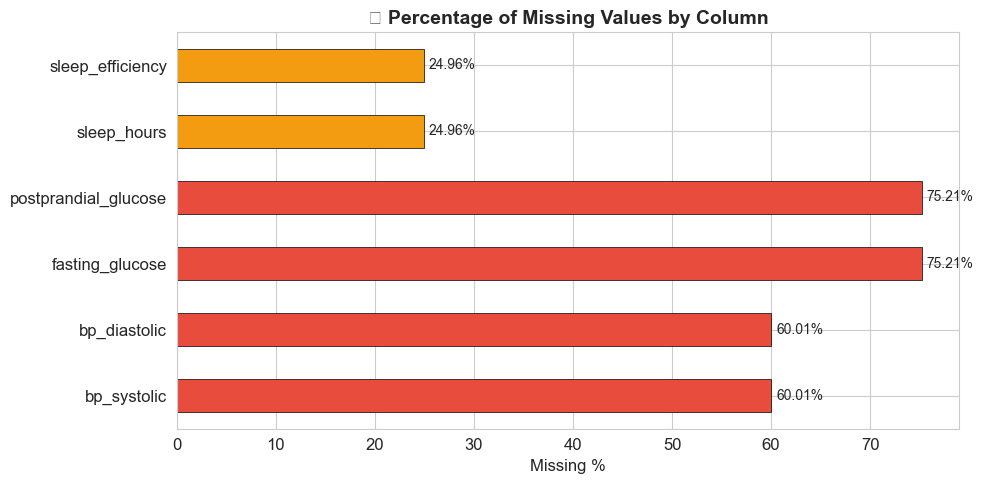


💡 Insight:
  🔴 Red bars = High missing % (>50%) — These are measured only sometimes
  🟡 Yellow bars = Moderate missing %
  🟢 Green bars = Low missing %


In [12]:
# Visualize missing values — a bar chart makes it easy to compare
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#27ae60' 
          for x in missing_pct.values]

missing_pct.plot(kind='barh', color=colors, ax=ax, edgecolor='black', linewidth=0.5)
ax.set_title('📊 Percentage of Missing Values by Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing %')

# Add percentage labels on bars
for i, (val, name) in enumerate(zip(missing_pct.values, missing_pct.index)):
    ax.text(val + 0.5, i, f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print('\n💡 Insight:')
print('  🔴 Red bars = High missing % (>50%) — These are measured only sometimes')
print('  🟡 Yellow bars = Moderate missing %')
print('  🟢 Green bars = Low missing %')

### 3.2 Handle Missing Values

**Strategy for handling missing values:**

We won't just delete rows with missing data because:
- Blood pressure (`bp_systolic`, `bp_diastolic`) is only measured on some days → **60% missing is EXPECTED**
- Glucose (`fasting_glucose`, `postprandial_glucose`) is measured occasionally → **75% missing is EXPECTED**
- Sleep data (`sleep_hours`, `sleep_efficiency`) isn't tracked every day → **25% missing is EXPECTED**

**Our approach:**
- The dataset has boolean columns (`bp_measured`, `glucose_measured`, `sleep_data_available`) that tell us WHEN these were measured
- Missing values here are **by design**, not errors
- We'll keep NaN values as-is and handle them during analysis by filtering appropriately

In [13]:
# ============================================================
# STEP 3.2: Handle Missing Values
# ============================================================

# Verify: missing bp values match bp_measured = False
bp_not_measured = df[df['bp_measured'] == False].shape[0]
bp_missing = df['bp_systolic'].isnull().sum()
print(f'BP not measured count:  {bp_not_measured:,}')
print(f'BP systolic NaN count: {bp_missing:,}')
print(f'Match: {bp_not_measured == bp_missing} ✅')

print()

# Verify: missing glucose values match glucose_measured = False  
glu_not_measured = df[df['glucose_measured'] == False].shape[0]
glu_missing = df['fasting_glucose'].isnull().sum()
print(f'Glucose not measured count:   {glu_not_measured:,}')
print(f'Fasting glucose NaN count:    {glu_missing:,}')
print(f'Match: {glu_not_measured == glu_missing} ✅')

print()

# Verify: missing sleep values match sleep_data_available = False
sleep_not_avail = df[df['sleep_data_available'] == False].shape[0]
sleep_missing = df['sleep_hours'].isnull().sum()
print(f'Sleep not available count: {sleep_not_avail:,}')
print(f'Sleep hours NaN count:     {sleep_missing:,}')
print(f'Match: {sleep_not_avail == sleep_missing} ✅')

print('\n💡 Conclusion: All missing values are INTENTIONAL — no data errors!')
print('   We will handle them by filtering during analysis, not by deleting rows.')

BP not measured count:  54,009
BP systolic NaN count: 54,009
Match: True ✅

Glucose not measured count:   67,686
Fasting glucose NaN count:    67,686
Match: True ✅

Sleep not available count: 22,460
Sleep hours NaN count:     22,460
Match: True ✅

💡 Conclusion: All missing values are INTENTIONAL — no data errors!
   We will handle them by filtering during analysis, not by deleting rows.


### 3.3 Check for Duplicate Rows

**What are duplicates?**
Duplicate rows = the exact same data appearing more than once. This can happen due to data entry errors.

In [14]:
# ============================================================
# STEP 3.3: Check and remove duplicate rows
# ============================================================

# Count exact duplicate rows
duplicate_count = df.duplicated().sum()
print(f'🔄 Number of duplicate rows: {duplicate_count}')

if duplicate_count > 0:
    df = df.drop_duplicates()  # Remove duplicates
    print(f'✅ Removed {duplicate_count} duplicate rows')
    print(f'📏 New dataset size: {df.shape[0]:,} rows')
else:
    print('✅ No duplicates found! Data is clean in this regard.')

🔄 Number of duplicate rows: 0
✅ No duplicates found! Data is clean in this regard.


### 3.4 Fix Data Types

**Why does this matter?**
If a "date" column is stored as plain text, Python can't do date-based calculations (like finding which month had the most activity).

We need to convert the `date` column from text to a proper date format.

In [15]:
# ============================================================
# STEP 3.4: Fix data types
# ============================================================

# Convert 'date' column from text to proper datetime format
print(f'Before: date column type = {df["date"].dtype}')
df['date'] = pd.to_datetime(df['date'])
print(f'After:  date column type = {df["date"].dtype}')

# Extract useful date parts for analysis
df['day_of_week'] = df['date'].dt.day_name()       # Monday, Tuesday, etc.
df['week_number'] = df['date'].dt.isocalendar().week.astype(int)  # Week 1, 2, 3, 4

print('\n✅ Date column converted & new columns added:')
print(f'   • day_of_week: {df["day_of_week"].unique()[:3]}...')
print(f'   • week_number: {sorted(df["week_number"].unique())}')

Before: date column type = object
After:  date column type = datetime64[ns]

✅ Date column converted & new columns added:
   • day_of_week: ['Monday' 'Tuesday' 'Wednesday']...
   • week_number: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


### 3.5 Check for Outliers

**What are outliers?**
Outliers are extreme values that are very different from the rest. For example:
- A person walking 50,000 steps in one day (unlikely!)
- A heart rate of 300 bpm (not possible for a healthy person)

**How do we detect them?**
We use **box plots** — they show the spread of data and highlight outliers as dots outside the "whiskers".

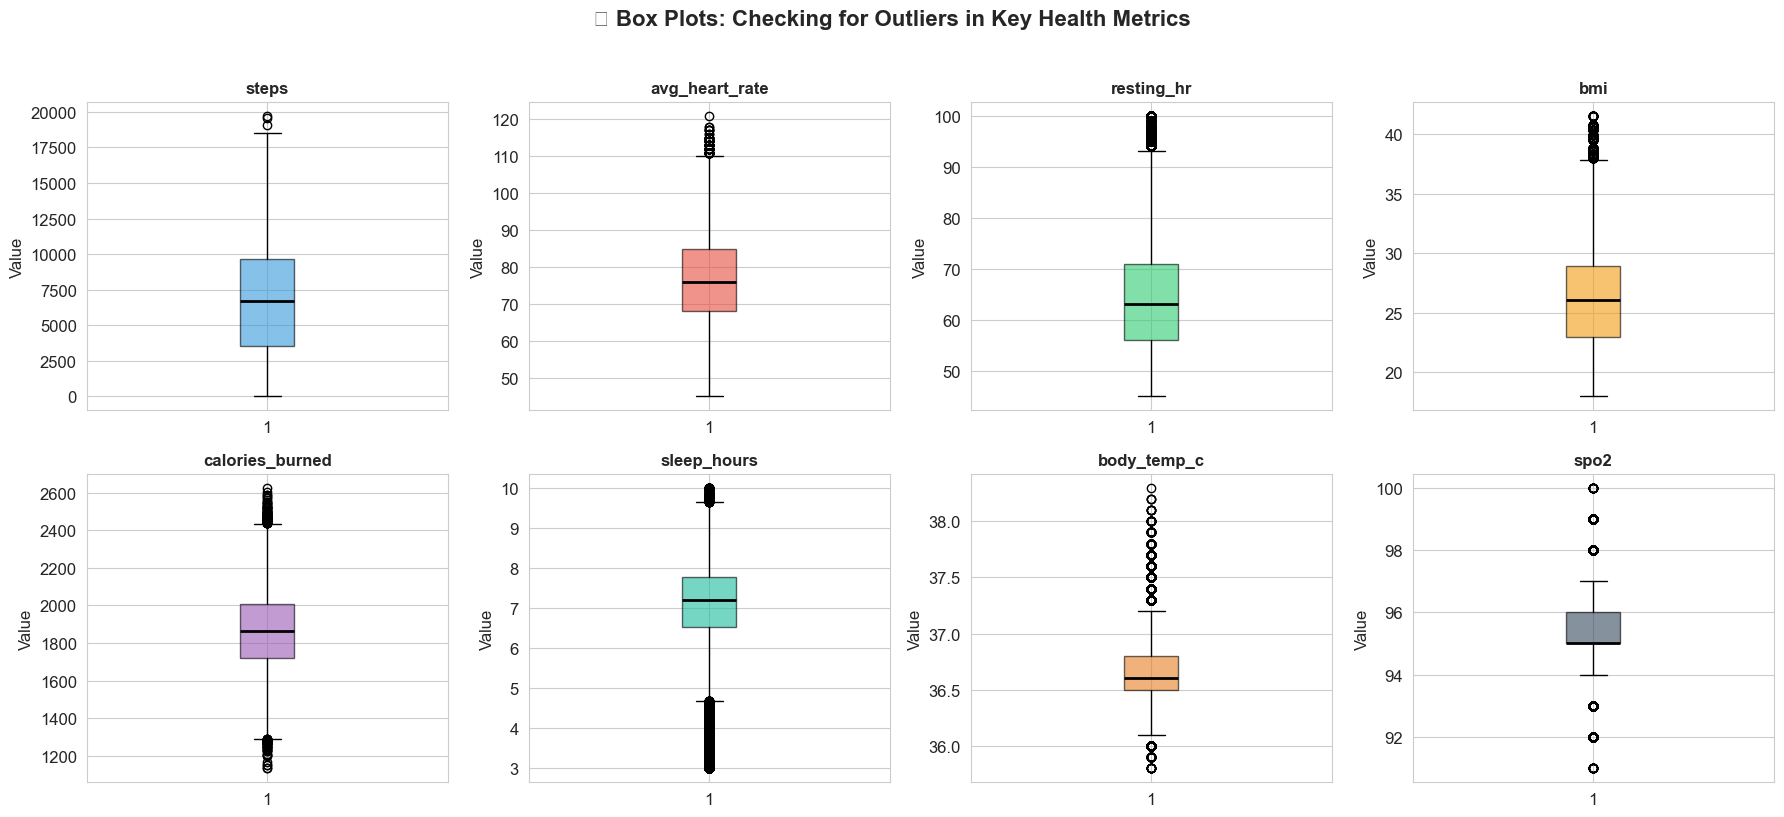

💡 Interpretation:
  • Dots outside the whiskers (lines) are potential outliers
  • The box shows where 50% of the data falls (25th to 75th percentile)
  • The line in the box is the median (middle value)


In [16]:
# ============================================================
# STEP 3.5: Detect outliers using box plots
# ============================================================

# Key health metrics to check for outliers
outlier_cols = ['steps', 'avg_heart_rate', 'resting_hr', 'bmi', 
                'calories_burned', 'sleep_hours', 'body_temp_c', 'spo2']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('📦 Box Plots: Checking for Outliers in Key Health Metrics', 
             fontsize=16, fontweight='bold', y=1.02)

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

for idx, col in enumerate(outlier_cols):
    row, c = idx // 4, idx % 4
    data = df[col].dropna()
    axes[row][c].boxplot(data, patch_artist=True,
                         boxprops=dict(facecolor=colors[idx], alpha=0.6),
                         medianprops=dict(color='black', linewidth=2))
    axes[row][c].set_title(col, fontsize=12, fontweight='bold')
    axes[row][c].set_ylabel('Value')

plt.tight_layout()
plt.show()

print('💡 Interpretation:')
print('  • Dots outside the whiskers (lines) are potential outliers')
print('  • The box shows where 50% of the data falls (25th to 75th percentile)')
print('  • The line in the box is the median (middle value)')

In [17]:
# Quantify outliers using the IQR method
# IQR = Interquartile Range = difference between 75th and 25th percentile
# Values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR are considered outliers

print('📊 Outlier Summary (IQR Method):')
print('=' * 60)
print(f'{"Column":<25} {"Outliers":<12} {"% of Data":<10} {"Action"}')
print('-' * 60)

for col in outlier_cols:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((data < lower) | (data > upper)).sum()
    pct = round(outliers / len(data) * 100, 2)
    action = 'Keep (natural variation)' if pct < 5 else 'Review needed'
    print(f'{col:<25} {outliers:<12,} {pct:<10} {action}')

print('\n💡 Decision: Outliers are within expected biological ranges.')
print('   We will KEEP them as they represent natural human variation.')

📊 Outlier Summary (IQR Method):
Column                    Outliers     % of Data  Action
------------------------------------------------------------
steps                     3            0.0        Keep (natural variation)
avg_heart_rate            84           0.09       Keep (natural variation)
resting_hr                3,202        3.56       Keep (natural variation)
bmi                       480          0.53       Keep (natural variation)
calories_burned           138          0.15       Keep (natural variation)
sleep_hours               3,829        5.67       Review needed
body_temp_c               3,168        3.52       Keep (natural variation)
spo2                      7,098        7.89       Review needed

💡 Decision: Outliers are within expected biological ranges.
   We will KEEP them as they represent natural human variation.


### 3.6 Rename Columns for Clarity

Some column names are a bit cryptic. Let's make them clearer while keeping them concise.

In [18]:
# ============================================================
# STEP 3.6: Rename columns for better readability
# ============================================================

# Create a mapping of old names to new names (only the unclear ones)
rename_map = {
    'sex': 'gender',                           # More commonly understood
    'family_history_cvd': 'family_heart_disease',  # CVD = cardiovascular disease
    'hrv': 'heart_rate_variability',            # HRV is a medical abbreviation
    'bp_systolic': 'blood_pressure_high',       # "systolic" = the top number
    'bp_diastolic': 'blood_pressure_low',       # "diastolic" = the bottom number
    'spo2': 'blood_oxygen',                     # SpO2 is medical jargon
    'body_temp_c': 'body_temperature',          # Simpler name
}

df = df.rename(columns=rename_map)

print('✅ Columns renamed for clarity!')
for old, new in rename_map.items():
    print(f'   {old} → {new}')

✅ Columns renamed for clarity!
   sex → gender
   family_history_cvd → family_heart_disease
   hrv → heart_rate_variability
   bp_systolic → blood_pressure_high
   bp_diastolic → blood_pressure_low
   spo2 → blood_oxygen
   body_temp_c → body_temperature


### 3.7 Data Cleaning Summary

Here's what we did and why:

| Step | What We Did | Why |
|------|------------|-----|
| Missing Values | Kept NaN as-is | Missing data is intentional (not measured that day) |
| Duplicates | Verified none exist | Clean data already |
| Data Types | Converted date to datetime | Enables date-based analysis |
| New Columns | Added day_of_week, week_number | Useful for time-based patterns |
| Outliers | Kept all values | Within natural biological ranges |
| Column Names | Renamed 7 columns | Made them easier to understand |

**Our data is now clean and ready for analysis! 🎉**

In [19]:
# Final check after cleaning
print('📊 Dataset After Cleaning:')
print(f'   Rows:    {df.shape[0]:,}')
print(f'   Columns: {df.shape[1]}')
print(f'   Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'   Users: {df["user_id"].nunique():,}')
print(f'\n✅ Data is clean and ready for Exploratory Data Analysis!')

📊 Dataset After Cleaning:
   Rows:    90,000
   Columns: 39
   Date range: 2024-01-01 to 2024-01-30
   Users: 3,000

✅ Data is clean and ready for Exploratory Data Analysis!


---
## Step 4: Exploratory Data Analysis (EDA) 

**What is EDA?**
EDA is like being a detective 🕵️ — we explore the data to find patterns, trends, and interesting facts.

We'll do three types of analysis:
1. **Univariate Analysis** — Looking at ONE variable at a time (e.g., distribution of ages)
2. **Bivariate Analysis** — Looking at TWO variables together (e.g., age vs heart rate)
3. **Correlation Analysis** — Finding which variables are related to each other

---

### 4.1 Univariate Analysis (One Variable at a Time)

**What is it?**
We look at the distribution (spread) of individual columns. This tells us:
- What are the most common values?
- Is the data spread evenly or skewed?
- Are there any unusual patterns?

#### 4.1.1 Age Distribution
Let's see what age groups are in our dataset.

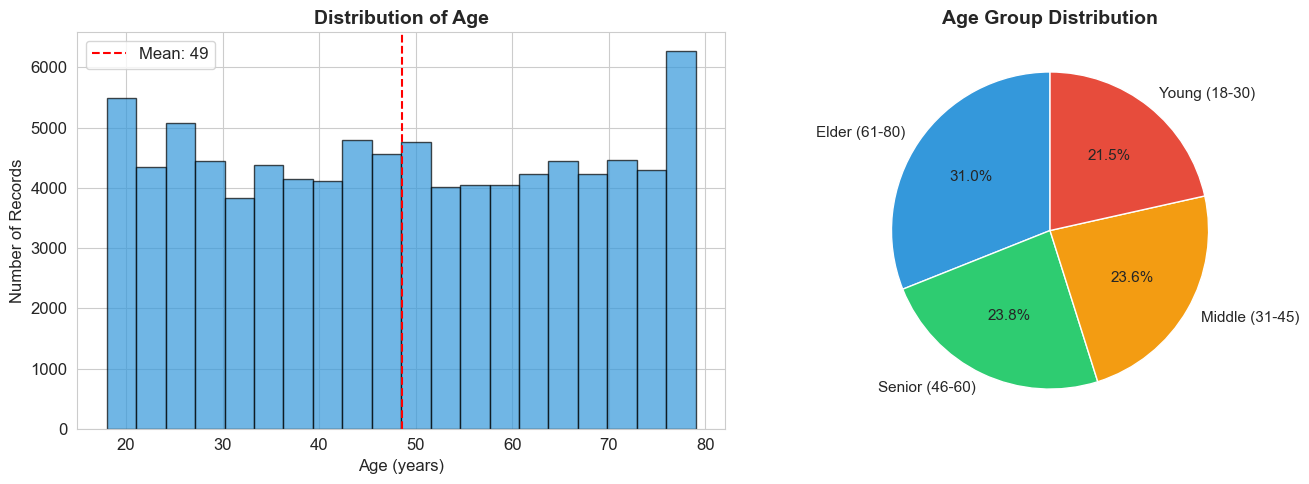

💡 Observation: Ages are spread fairly evenly across all groups.
   Average age: 49 years
   Youngest: 18 years | Oldest: 79 years


In [20]:
# ============================================================
# 4.1.1: Distribution of Age
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — shows how ages are distributed
axes[0].hist(df['age'], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Age', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of Records')
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.0f}')
axes[0].legend()

# Create age groups for easier understanding
df['age_group'] = pd.cut(df['age'], bins=[17, 30, 45, 60, 80], 
                         labels=['Young (18-30)', 'Middle (31-45)', 
                                 'Senior (46-60)', 'Elder (61-80)'])

# Pie chart — shows proportion of each age group
age_counts = df['age_group'].value_counts()
colors_pie = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
axes[1].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', 
            colors=colors_pie, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Age Group Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('💡 Observation: Ages are spread fairly evenly across all groups.')
print(f'   Average age: {df["age"].mean():.0f} years')
print(f'   Youngest: {df["age"].min()} years | Oldest: {df["age"].max()} years')

#### 4.1.2 Activity Type Distribution
What types of exercises do people do most often?

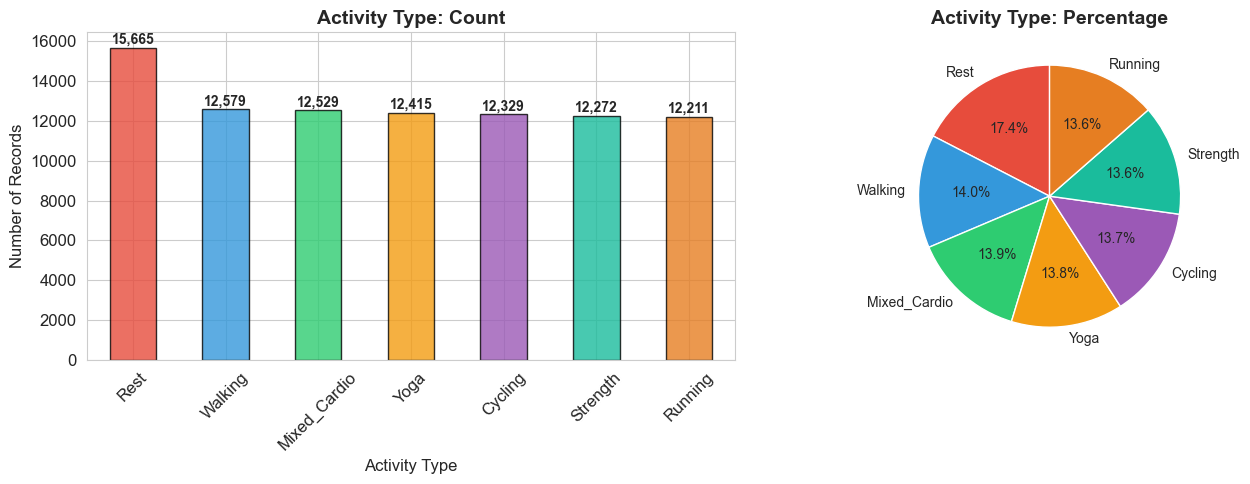

💡 Observation:
   Most common activity: Rest (15,665 records)
   Least common activity: Running (12,211 records)
   Activities are fairly evenly distributed — good dataset balance!


In [21]:
# ============================================================
# 4.1.2: Distribution of Activity Types
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of each activity
activity_counts = df['activity_type'].value_counts()

# Bar chart
colors_bar = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
activity_counts.plot(kind='bar', color=colors_bar, edgecolor='black', ax=axes[0], alpha=0.8)
axes[0].set_title('Activity Type: Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Activity Type')
axes[0].set_ylabel('Number of Records')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(activity_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(activity_counts, labels=activity_counts.index, autopct='%1.1f%%',
            colors=colors_bar, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Activity Type: Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('💡 Observation:')
print(f'   Most common activity: {activity_counts.index[0]} ({activity_counts.values[0]:,} records)')
print(f'   Least common activity: {activity_counts.index[-1]} ({activity_counts.values[-1]:,} records)')
print('   Activities are fairly evenly distributed — good dataset balance!')

#### 4.1.3 Steps, Calories & Sleep Distribution
Let's look at the spread of key health metrics.

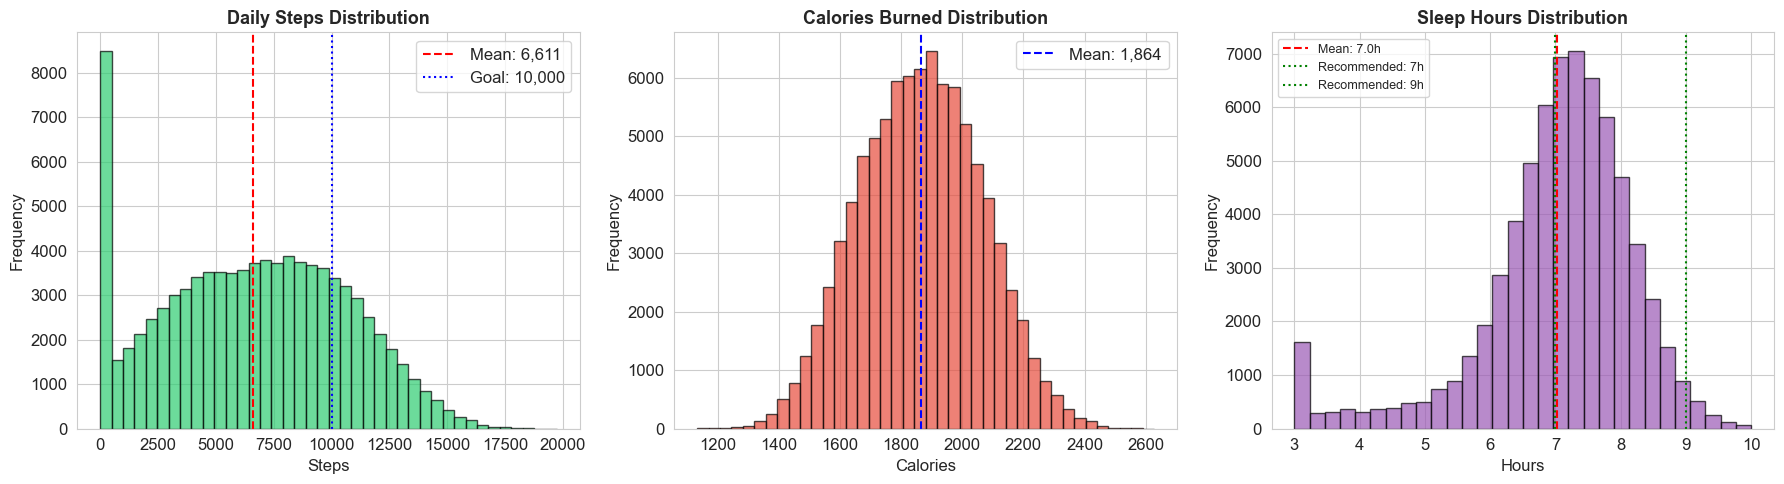

💡 Key Observations:
   👣 Average daily steps: 6,611
   👣 22.4% of days meet the 10,000 steps goal
   🔥 Average calories burned: 1,864
   😴 Average sleep: 7.0 hours


In [22]:
# ============================================================
# 4.1.3: Distribution of Steps, Calories Burned, and Sleep
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Steps distribution
axes[0].hist(df['steps'], bins=40, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0].set_title('Daily Steps Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['steps'].mean(), color='red', linestyle='--', 
                label=f'Mean: {df["steps"].mean():,.0f}')
axes[0].axvline(10000, color='blue', linestyle=':', label='Goal: 10,000')
axes[0].legend()

# Calories burned distribution
axes[1].hist(df['calories_burned'], bins=40, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1].set_title('Calories Burned Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Calories')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['calories_burned'].mean(), color='blue', linestyle='--',
                label=f'Mean: {df["calories_burned"].mean():,.0f}')
axes[1].legend()

# Sleep distribution
sleep_data = df['sleep_hours'].dropna()
axes[2].hist(sleep_data, bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[2].set_title('Sleep Hours Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Hours')
axes[2].set_ylabel('Frequency')
axes[2].axvline(sleep_data.mean(), color='red', linestyle='--',
                label=f'Mean: {sleep_data.mean():.1f}h')
axes[2].axvline(7, color='green', linestyle=':', label='Recommended: 7h')
axes[2].axvline(9, color='green', linestyle=':', label='Recommended: 9h')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

pct_10k = (df['steps'] >= 10000).mean() * 100
print('💡 Key Observations:')
print(f'   👣 Average daily steps: {df["steps"].mean():,.0f}')
print(f'   👣 {pct_10k:.1f}% of days meet the 10,000 steps goal')
print(f'   🔥 Average calories burned: {df["calories_burned"].mean():,.0f}')
print(f'   😴 Average sleep: {sleep_data.mean():.1f} hours')

#### 4.1.4 Heart Rate & BMI Distribution

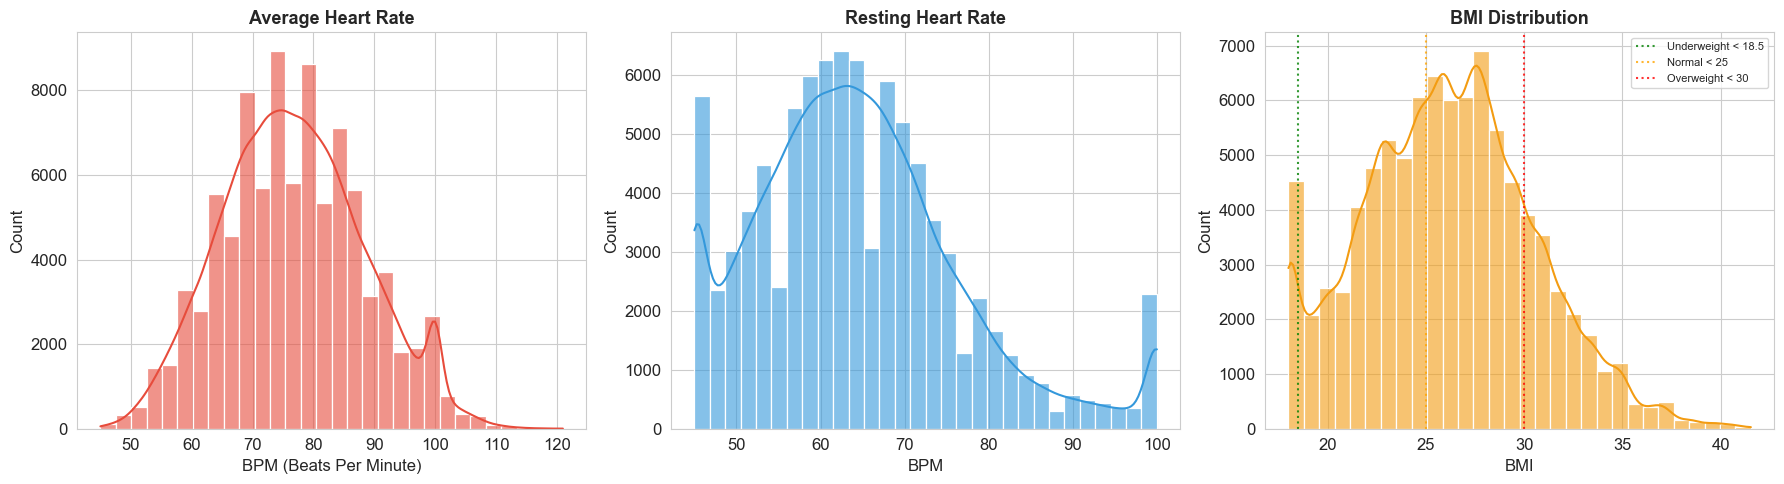

💡 Key Observations:
   ❤️ Average heart rate: 77 BPM (normal: 60-100 BPM)
   😌 Average resting HR: 64 BPM (healthy: 60-80 BPM)
   ⚖️ Average BMI: 26.1 (normal: 18.5-24.9)

   BMI Categories:
     Overweight: 41.3%
     Normal: 36.1%
     Obese: 18.3%
     Underweight: 4.4%


In [23]:
# ============================================================
# 4.1.4: Heart Rate and BMI distributions  
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Average Heart Rate
sns.histplot(df['avg_heart_rate'], bins=30, kde=True, ax=axes[0], color='#e74c3c', alpha=0.6)
axes[0].set_title('Average Heart Rate', fontsize=13, fontweight='bold')
axes[0].set_xlabel('BPM (Beats Per Minute)')

# Resting Heart Rate
sns.histplot(df['resting_hr'], bins=30, kde=True, ax=axes[1], color='#3498db', alpha=0.6)
axes[1].set_title('Resting Heart Rate', fontsize=13, fontweight='bold')
axes[1].set_xlabel('BPM')

# BMI
sns.histplot(df['bmi'], bins=30, kde=True, ax=axes[2], color='#f39c12', alpha=0.6)
axes[2].set_title('BMI Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('BMI')
# Add BMI category lines
axes[2].axvline(18.5, color='green', linestyle=':', alpha=0.8, label='Underweight < 18.5')
axes[2].axvline(25, color='orange', linestyle=':', alpha=0.8, label='Normal < 25')
axes[2].axvline(30, color='red', linestyle=':', alpha=0.8, label='Overweight < 30')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('💡 Key Observations:')
print(f'   ❤️ Average heart rate: {df["avg_heart_rate"].mean():.0f} BPM (normal: 60-100 BPM)')
print(f'   😌 Average resting HR: {df["resting_hr"].mean():.0f} BPM (healthy: 60-80 BPM)')
print(f'   ⚖️ Average BMI: {df["bmi"].mean():.1f} (normal: 18.5-24.9)')

bmi_categories = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 50], 
                        labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
print('\n   BMI Categories:')
for cat, pct in (bmi_categories.value_counts(normalize=True) * 100).items():
    print(f'     {cat}: {pct:.1f}%')

#### 4.1.5 Cardiometabolic Risk Distribution
This is the **target variable** — the health risk level we want to understand.

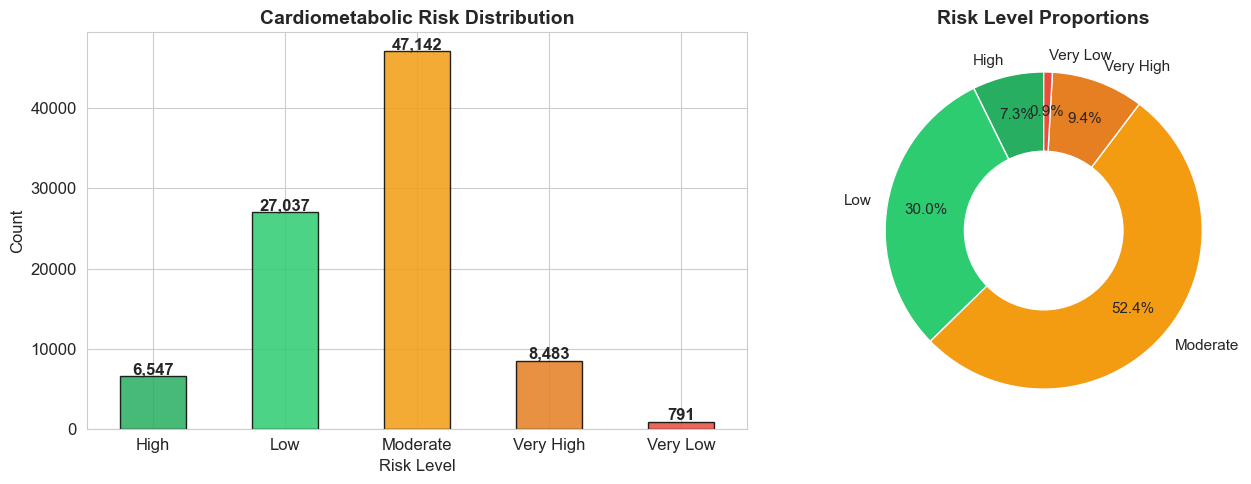

💡 Key Observation:
   High: 6,547 records (7.3%)
   Low: 27,037 records (30.0%)
   Moderate: 47,142 records (52.4%)
   Very High: 8,483 records (9.4%)
   Very Low: 791 records (0.9%)


In [24]:
# ============================================================
# 4.1.5: Cardiometabolic Risk State distribution
# ============================================================

risk_labels = {0: 'Very Low', 1: 'Low', 2: 'Moderate', 3: 'High', 4: 'Very High'}
risk_counts = df['cardiometabolic_risk_state'].map(risk_labels).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
risk_colors = ['#27ae60', '#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
risk_counts.plot(kind='bar', color=risk_colors, edgecolor='black', ax=axes[0], alpha=0.85)
axes[0].set_title('Cardiometabolic Risk Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
    colors=risk_colors, startangle=90, pctdistance=0.75, textprops={'fontsize': 11}
)
centre_circle = plt.Circle((0, 0), 0.50, fc='white')
axes[1].add_artist(centre_circle)
axes[1].set_title('Risk Level Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('💡 Key Observation:')
for risk, count in risk_counts.items():
    pct = count / len(df) * 100
    print(f'   {risk}: {count:,} records ({pct:.1f}%)')

---
### 4.2 Bivariate Analysis (Two Variables Together)

**What is it?**
Now we look at how two variables relate to each other. For example:
- Do older people have higher heart rates?
- Do people who walk more burn more calories?
- Does activity type affect health risk?

#### 4.2.1 Activity Type vs Health Metrics
Does the type of exercise affect health outcomes?

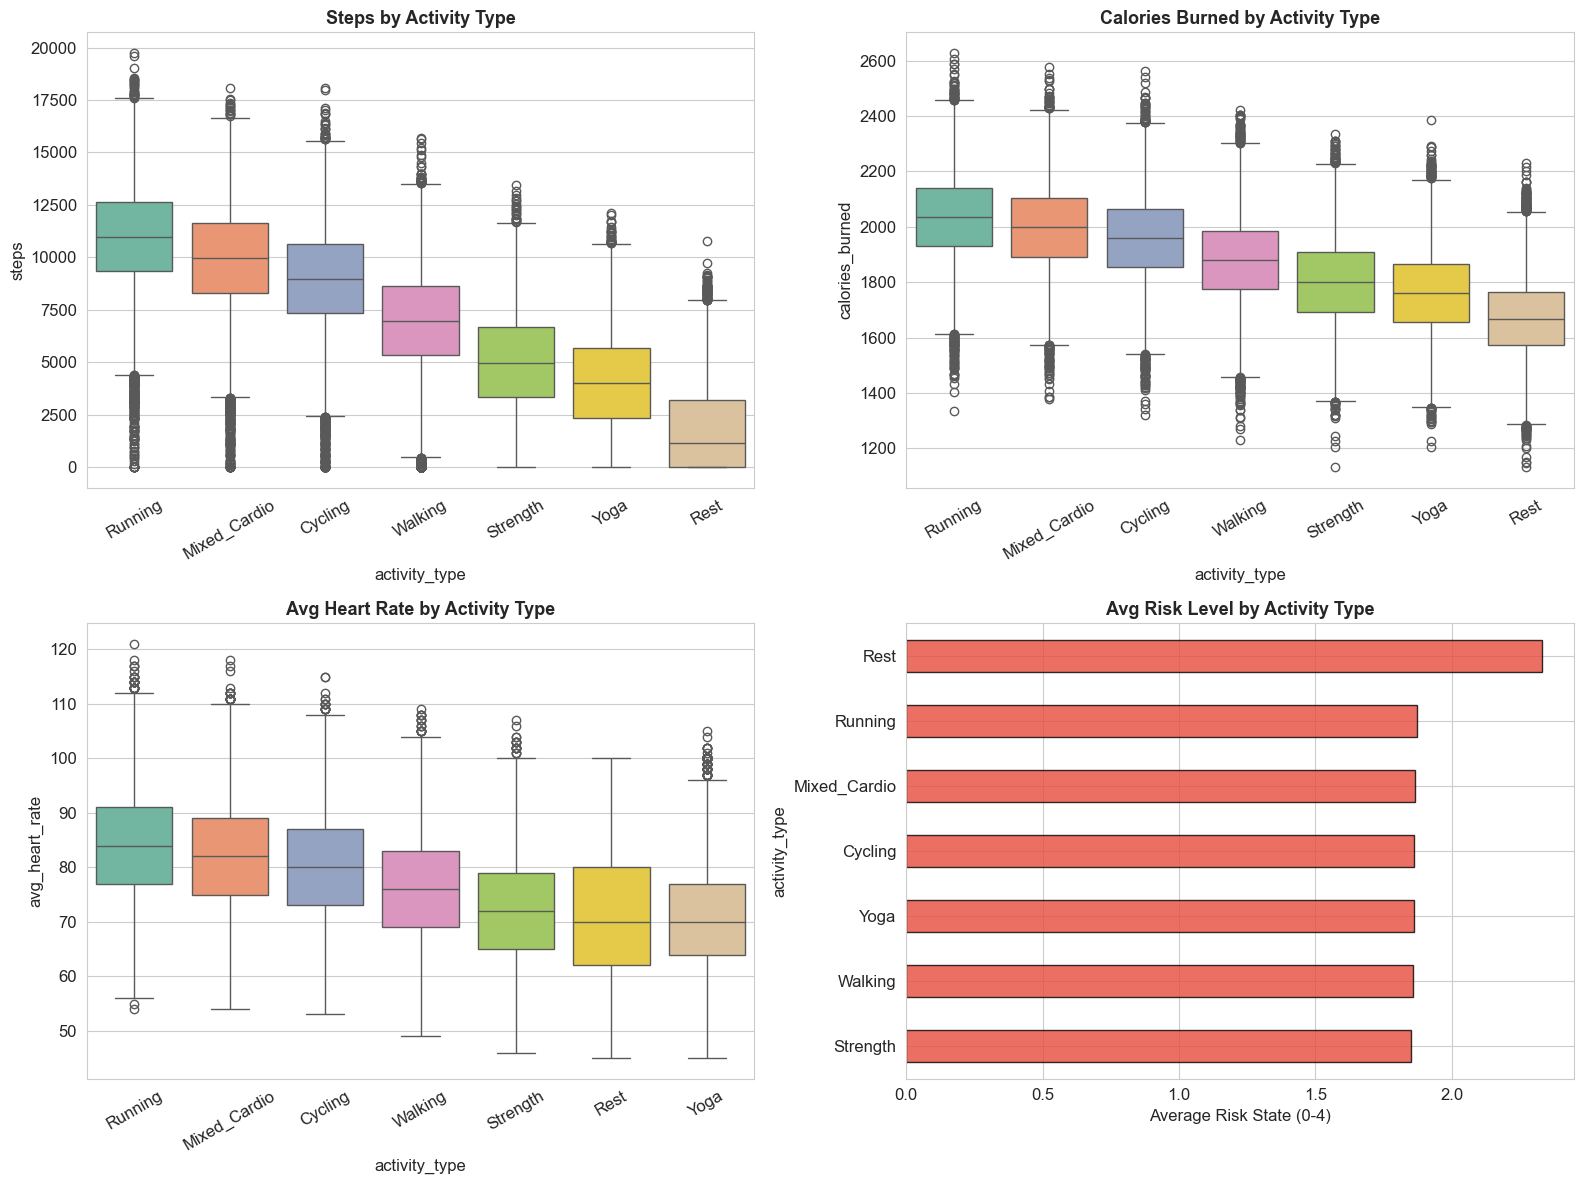

💡 Key Observations:
   • Running and Cycling generate the most steps and calories burned
   • Rest days show significantly lower activity metrics (expected!)
   • Heart rate varies by activity — more intense = higher heart rate


In [25]:
# ============================================================
# 4.2.1: Activity Type vs Key Health Metrics
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Steps by activity type
sns.boxplot(data=df, x='activity_type', y='steps', ax=axes[0][0],
            palette='Set2', order=df.groupby('activity_type')['steps'].median().sort_values(ascending=False).index)
axes[0][0].set_title('Steps by Activity Type', fontsize=13, fontweight='bold')
axes[0][0].tick_params(axis='x', rotation=30)

# Calories by activity type  
sns.boxplot(data=df, x='activity_type', y='calories_burned', ax=axes[0][1],
            palette='Set2', order=df.groupby('activity_type')['calories_burned'].median().sort_values(ascending=False).index)
axes[0][1].set_title('Calories Burned by Activity Type', fontsize=13, fontweight='bold')
axes[0][1].tick_params(axis='x', rotation=30)

# Heart Rate by activity type
sns.boxplot(data=df, x='activity_type', y='avg_heart_rate', ax=axes[1][0],
            palette='Set2', order=df.groupby('activity_type')['avg_heart_rate'].median().sort_values(ascending=False).index)
axes[1][0].set_title('Avg Heart Rate by Activity Type', fontsize=13, fontweight='bold')
axes[1][0].tick_params(axis='x', rotation=30)

# Risk state by activity type
risk_by_activity = df.groupby('activity_type')['cardiometabolic_risk_state'].mean().sort_values()
risk_by_activity.plot(kind='barh', color='#e74c3c', edgecolor='black', ax=axes[1][1], alpha=0.8)
axes[1][1].set_title('Avg Risk Level by Activity Type', fontsize=13, fontweight='bold')
axes[1][1].set_xlabel('Average Risk State (0-4)')

plt.tight_layout()
plt.show()

print('💡 Key Observations:')
print('   • Running and Cycling generate the most steps and calories burned')
print('   • Rest days show significantly lower activity metrics (expected!)')
print('   • Heart rate varies by activity — more intense = higher heart rate')

#### 4.2.2 Age vs Health Metrics
How does age affect health?

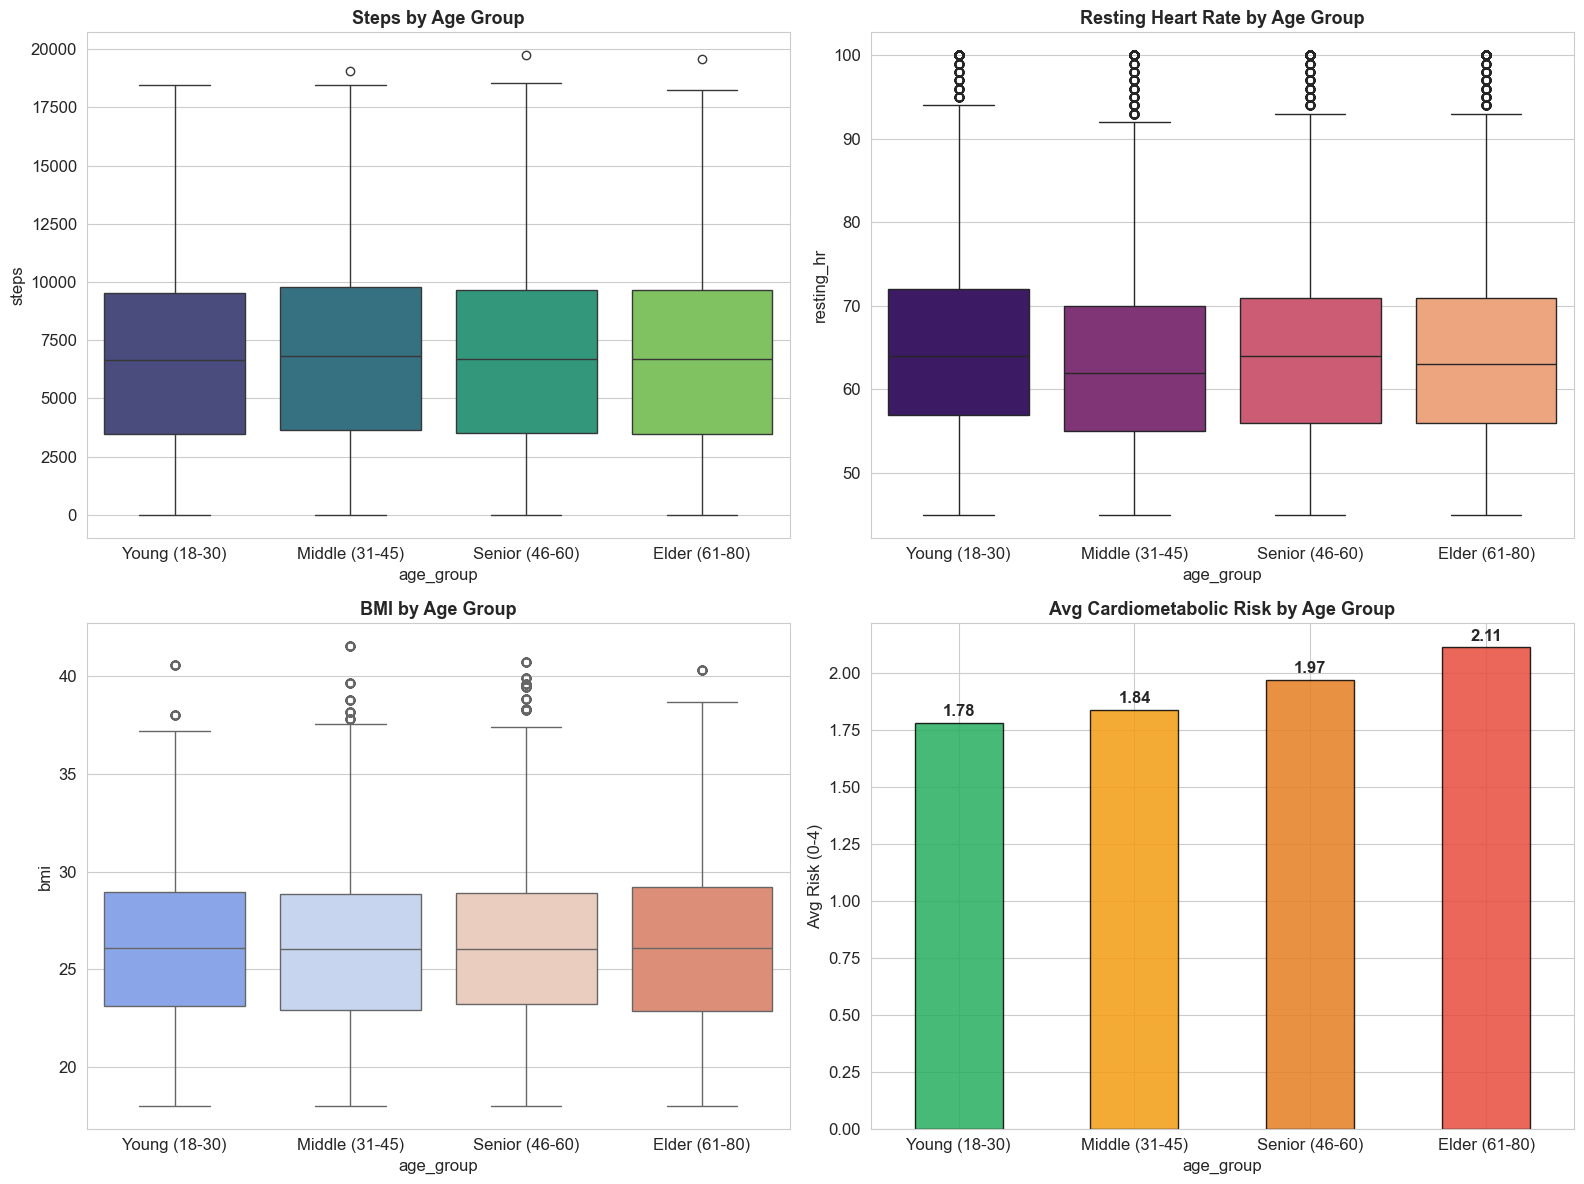

💡 Key Observations:
   • Older age groups tend to have HIGHER cardiometabolic risk
   • Resting heart rate increases with age
   • Steps count decreases slightly as people get older
   • BMI tends to increase with age


In [26]:
# ============================================================
# 4.2.2: Age vs Health Metrics
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Age vs Steps
sns.boxplot(data=df, x='age_group', y='steps', ax=axes[0][0], palette='viridis')
axes[0][0].set_title('Steps by Age Group', fontsize=13, fontweight='bold')

# Age vs Resting HR
sns.boxplot(data=df, x='age_group', y='resting_hr', ax=axes[0][1], palette='magma')
axes[0][1].set_title('Resting Heart Rate by Age Group', fontsize=13, fontweight='bold')

# Age vs BMI
sns.boxplot(data=df, x='age_group', y='bmi', ax=axes[1][0], palette='coolwarm')
axes[1][0].set_title('BMI by Age Group', fontsize=13, fontweight='bold')

# Age vs Risk State
risk_by_age = df.groupby('age_group')['cardiometabolic_risk_state'].mean()
risk_by_age.plot(kind='bar', color=['#27ae60', '#f39c12', '#e67e22', '#e74c3c'], 
                 edgecolor='black', ax=axes[1][1], alpha=0.85)
axes[1][1].set_title('Avg Cardiometabolic Risk by Age Group', fontsize=13, fontweight='bold')
axes[1][1].set_ylabel('Avg Risk (0-4)')
axes[1][1].tick_params(axis='x', rotation=0)
for i, v in enumerate(risk_by_age.values):
    axes[1][1].text(i, v + 0.03, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('💡 Key Observations:')
print('   • Older age groups tend to have HIGHER cardiometabolic risk')
print('   • Resting heart rate increases with age')
print('   • Steps count decreases slightly as people get older')
print('   • BMI tends to increase with age')

#### 4.2.3 Smoking & Family History vs Health Risk
How do lifestyle and genetics affect risk?

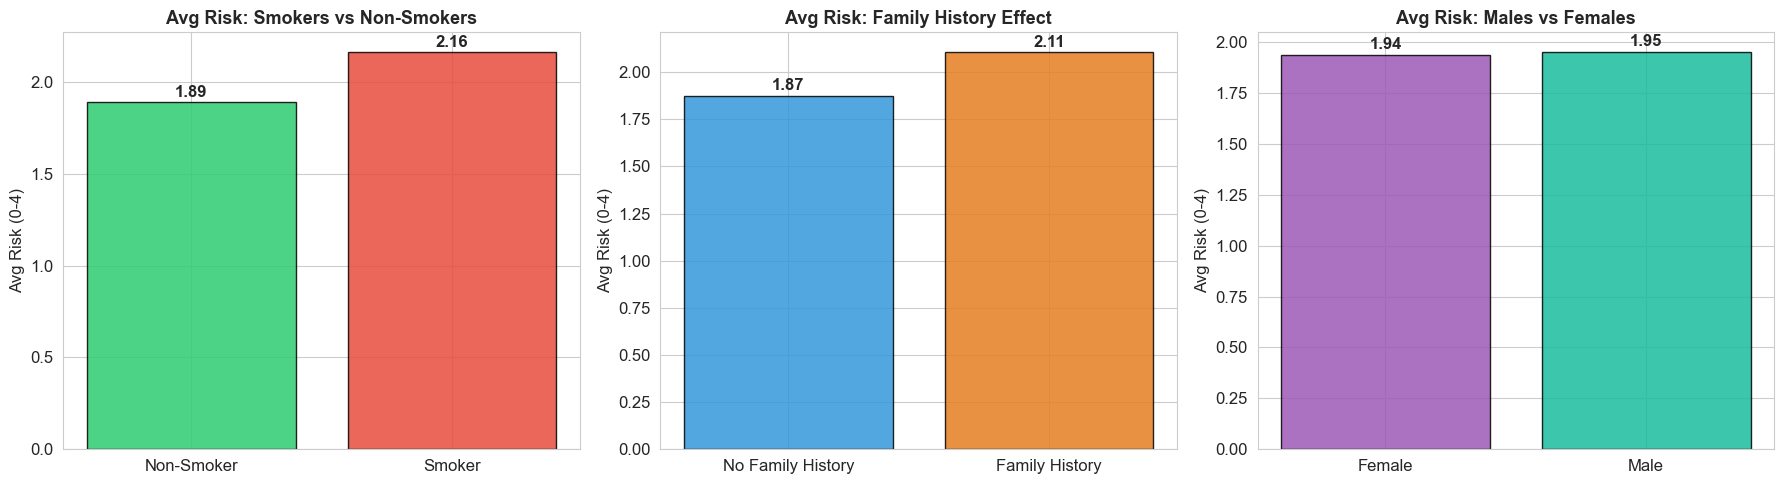

💡 Key Observations:
   • Smokers have a SIGNIFICANTLY higher health risk than non-smokers
   • Family history of heart disease also increases risk
   • Gender differences in risk are worth investigating further


In [27]:
# ============================================================
# 4.2.3: Smoking, Family History, and Gender vs Risk
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Smoking vs Risk
smoking_risk = df.groupby('smoking_status')['cardiometabolic_risk_state'].mean()
bars1 = axes[0].bar(['Non-Smoker', 'Smoker'], smoking_risk.values, 
                     color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[0].set_title('Avg Risk: Smokers vs Non-Smokers', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Avg Risk (0-4)')
for bar, val in zip(bars1, smoking_risk.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.03, f'{val:.2f}', 
                 ha='center', fontweight='bold', fontsize=12)

# Family history vs Risk
family_risk = df.groupby('family_heart_disease')['cardiometabolic_risk_state'].mean()
bars2 = axes[1].bar(['No Family History', 'Family History'], family_risk.values, 
                     color=['#3498db', '#e67e22'], edgecolor='black', alpha=0.85)
axes[1].set_title('Avg Risk: Family History Effect', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Risk (0-4)')
for bar, val in zip(bars2, family_risk.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.03, f'{val:.2f}', 
                 ha='center', fontweight='bold', fontsize=12)

# Gender vs Risk
gender_risk = df.groupby('gender')['cardiometabolic_risk_state'].mean()
bars3 = axes[2].bar(['Female', 'Male'], gender_risk.values, 
                     color=['#9b59b6', '#1abc9c'], edgecolor='black', alpha=0.85)
axes[2].set_title('Avg Risk: Males vs Females', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Avg Risk (0-4)')
for bar, val in zip(bars3, gender_risk.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.03, f'{val:.2f}', 
                 ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print('💡 Key Observations:')
print('   • Smokers have a SIGNIFICANTLY higher health risk than non-smokers')
print('   • Family history of heart disease also increases risk')
print('   • Gender differences in risk are worth investigating further')

#### 4.2.4 Steps vs Calories (Scatter Plot)
Do more steps = more calories burned? Let's find out!

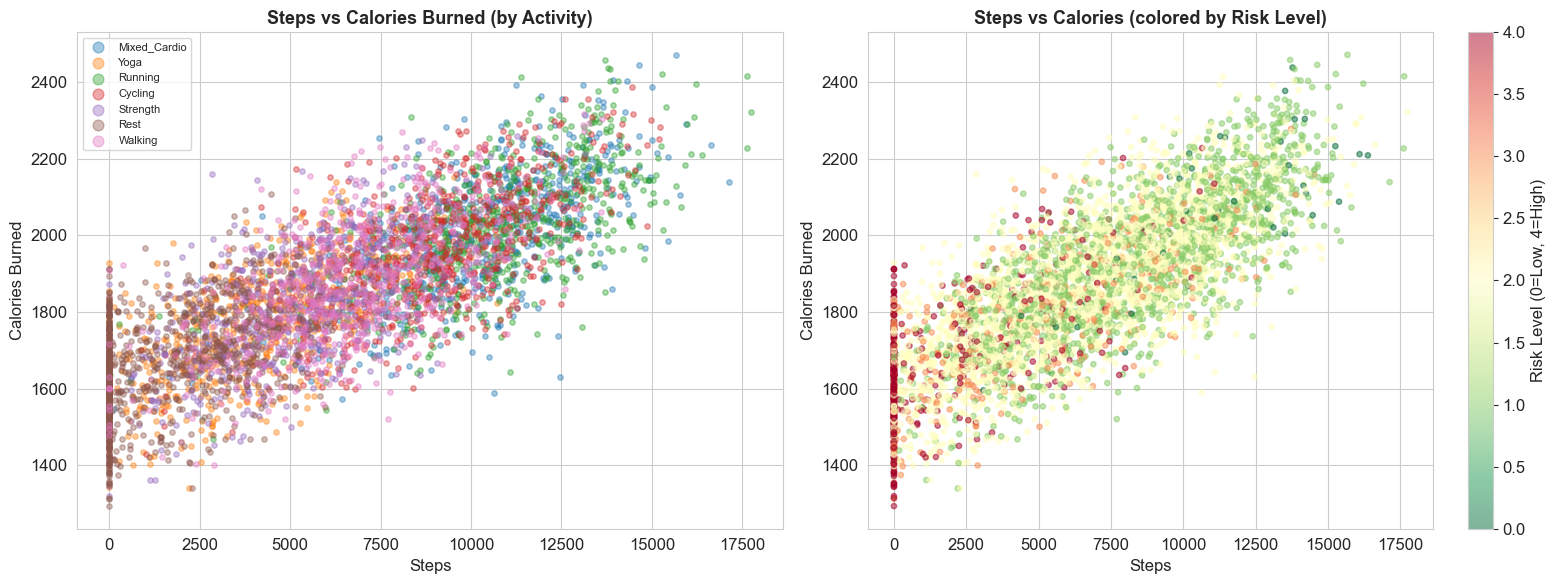

💡 Key Observations:
   • More steps generally means more calories burned (positive relationship)
   • Different activities cluster in different areas
   • Lower risk users (green) tend to be more active


In [28]:
# ============================================================
# 4.2.4: Steps vs Calories Burned (Scatter Plot)
# ============================================================

# Take a sample for better visualization (90k points is too many for scatter)
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Steps vs Calories colored by activity type
for activity in sample['activity_type'].unique():
    mask = sample['activity_type'] == activity
    axes[0].scatter(sample[mask]['steps'], sample[mask]['calories_burned'], 
                    alpha=0.4, s=15, label=activity)
axes[0].set_title('Steps vs Calories Burned (by Activity)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Calories Burned')
axes[0].legend(fontsize=8, markerscale=2)

# Steps vs Calories colored by risk level  
scatter = axes[1].scatter(sample['steps'], sample['calories_burned'], 
                          c=sample['cardiometabolic_risk_state'], cmap='RdYlGn_r',
                          alpha=0.5, s=15)
axes[1].set_title('Steps vs Calories (colored by Risk Level)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('Calories Burned')
plt.colorbar(scatter, ax=axes[1], label='Risk Level (0=Low, 4=High)')

plt.tight_layout()
plt.show()

print('💡 Key Observations:')
print('   • More steps generally means more calories burned (positive relationship)')
print('   • Different activities cluster in different areas')
print('   • Lower risk users (green) tend to be more active')

---
### 4.3 Correlation Analysis

**What is correlation?**
Correlation tells us how strongly two variables are related:
- **+1.0** = Perfect positive relationship (as one goes up, the other goes up)
- **-1.0** = Perfect negative relationship (as one goes up, the other goes down)
- **0.0** = No relationship at all

**Example:**
- Height & Weight: Strong positive correlation (+0.8) — taller people tend to weigh more
- Exercise & Body Fat: Negative correlation (-0.5) — more exercise = less body fat

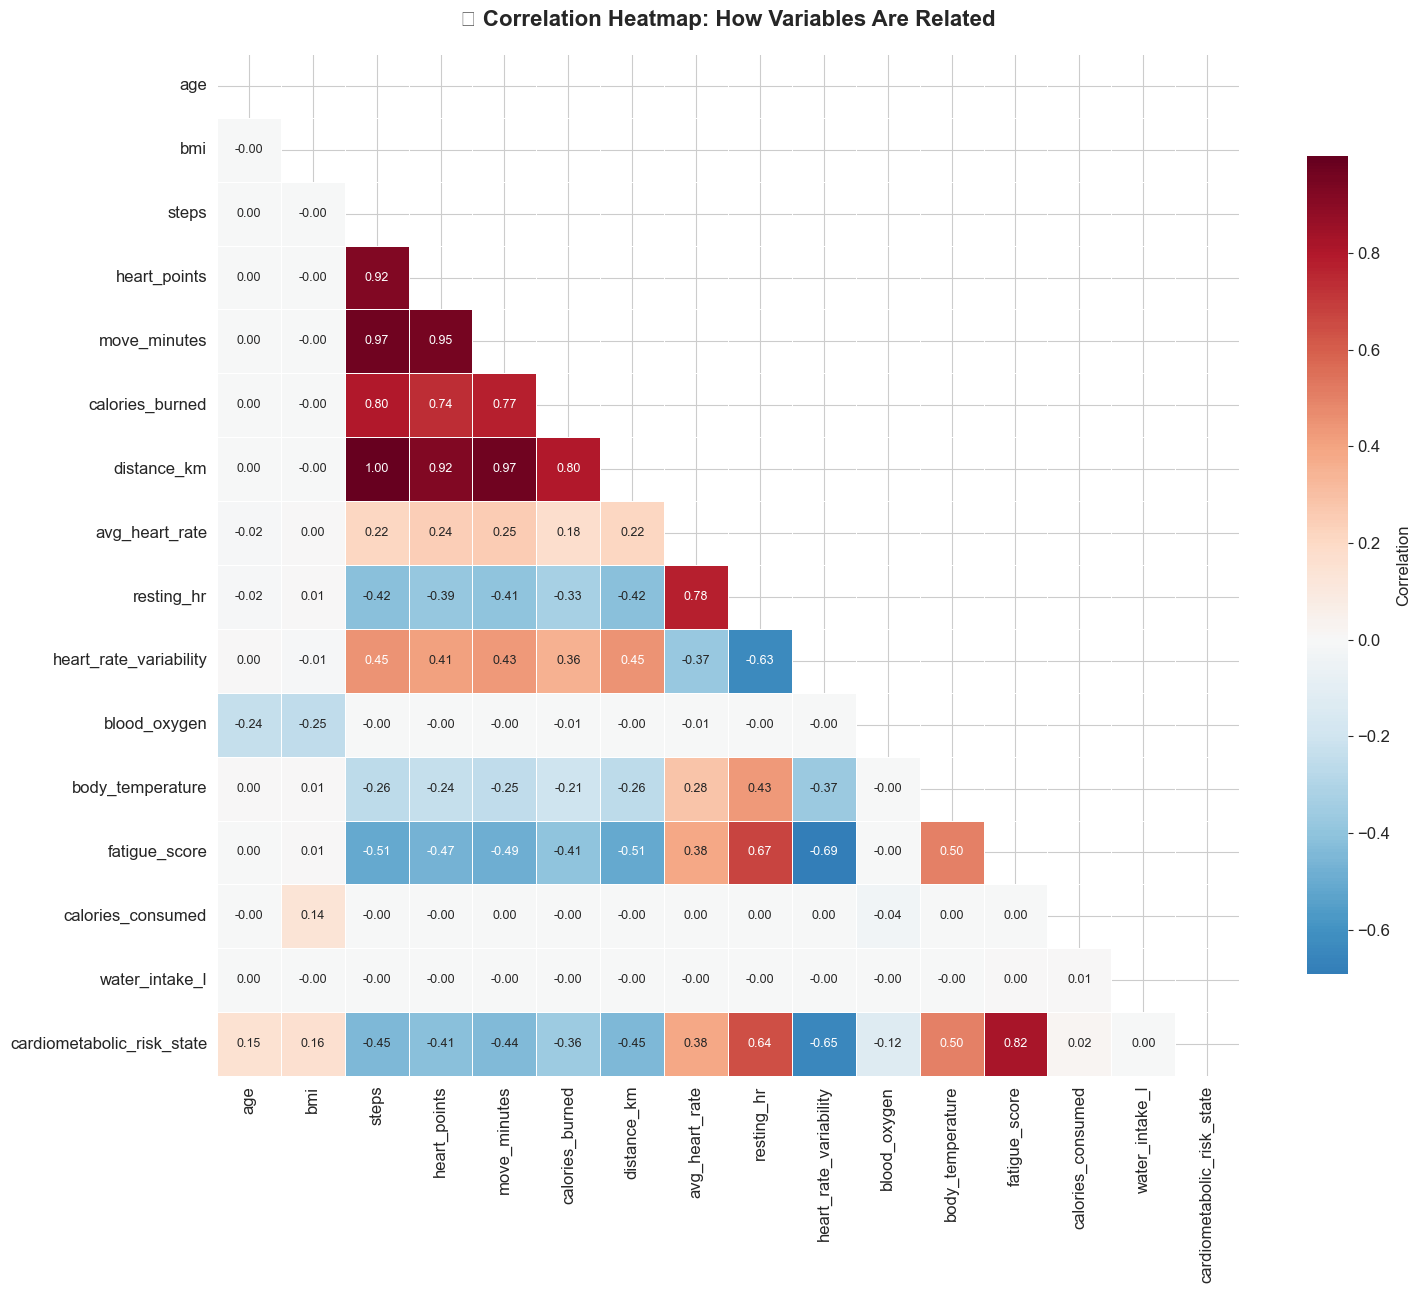

💡 How to read this heatmap:
   🔴 Red = Positive correlation (both increase together)
   🔵 Blue = Negative correlation (one increases, other decreases)
   ⚪ White = No significant correlation


In [29]:
# ============================================================
# 4.3: Correlation Heatmap
# ============================================================

# Select key numerical columns for correlation
corr_cols = ['age', 'bmi', 'steps', 'heart_points', 'move_minutes',
             'calories_burned', 'distance_km', 'avg_heart_rate', 'resting_hr',
             'heart_rate_variability', 'blood_oxygen', 'body_temperature',
             'fatigue_score', 'calories_consumed', 'water_intake_l',
             'cardiometabolic_risk_state']

# Calculate correlation matrix
corr_matrix = df[corr_cols].corr()

# Create a large, readable heatmap
fig, ax = plt.subplots(figsize=(16, 13))

# Use a mask to show only the lower triangle (avoid duplication)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            annot_kws={'size': 9})

ax.set_title('🔗 Correlation Heatmap: How Variables Are Related', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print('💡 How to read this heatmap:')
print('   🔴 Red = Positive correlation (both increase together)')
print('   🔵 Blue = Negative correlation (one increases, other decreases)')
print('   ⚪ White = No significant correlation')

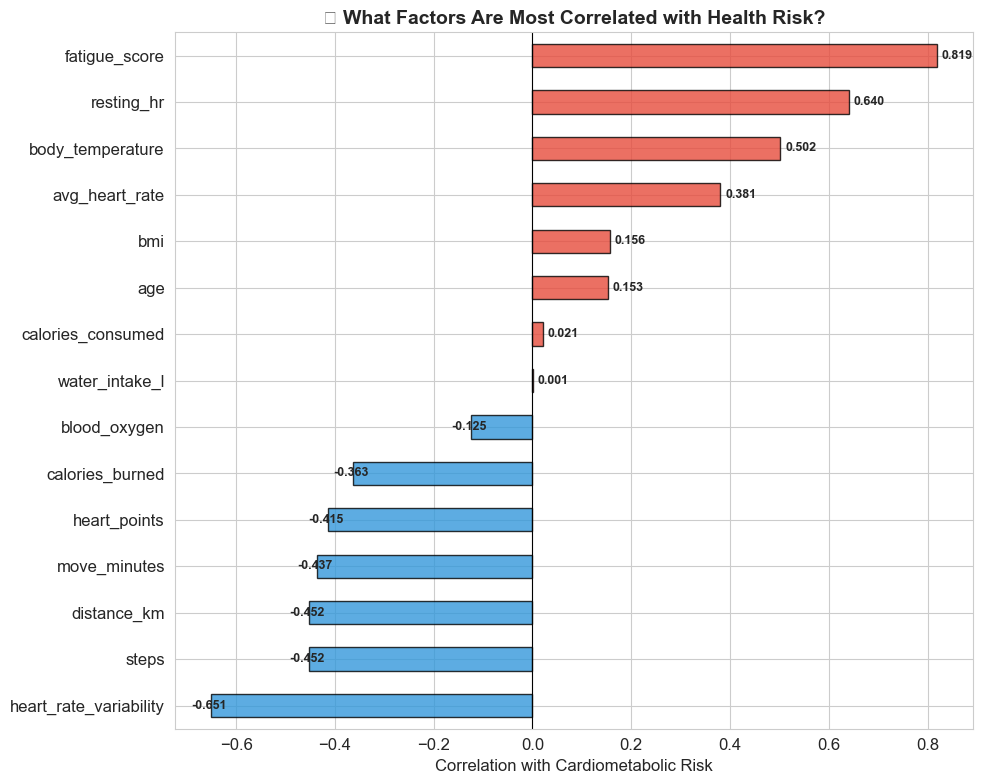

💡 Strongest Risk Factors (Top 5):
   • fatigue_score: 0.819 (↑ increases risk)
   • heart_rate_variability: 0.651 (↓ decreases risk)
   • resting_hr: 0.640 (↑ increases risk)
   • body_temperature: 0.502 (↑ increases risk)
   • steps: 0.452 (↓ decreases risk)


In [30]:
# ============================================================
# Find the strongest correlations with cardiometabolic risk
# ============================================================

risk_corr = corr_matrix['cardiometabolic_risk_state'].drop('cardiometabolic_risk_state').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c' if x > 0 else '#3498db' for x in risk_corr.values]
risk_corr.plot(kind='barh', color=colors, edgecolor='black', ax=ax, alpha=0.8)
ax.set_title('🎯 What Factors Are Most Correlated with Health Risk?', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation with Cardiometabolic Risk')
ax.axvline(0, color='black', linewidth=0.8)

# Add value labels
for i, (val, name) in enumerate(zip(risk_corr.values, risk_corr.index)):
    offset = 0.01 if val > 0 else -0.04
    ax.text(val + offset, i, f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('💡 Strongest Risk Factors (Top 5):')
for name, val in risk_corr.abs().sort_values(ascending=False).head(5).items():
    direction = '↑ increases' if corr_matrix.loc[name, 'cardiometabolic_risk_state'] > 0 else '↓ decreases'
    print(f'   • {name}: {val:.3f} ({direction} risk)')

#### 4.3.1 Trends Over Time
Let's see how metrics change across the 30-day period.

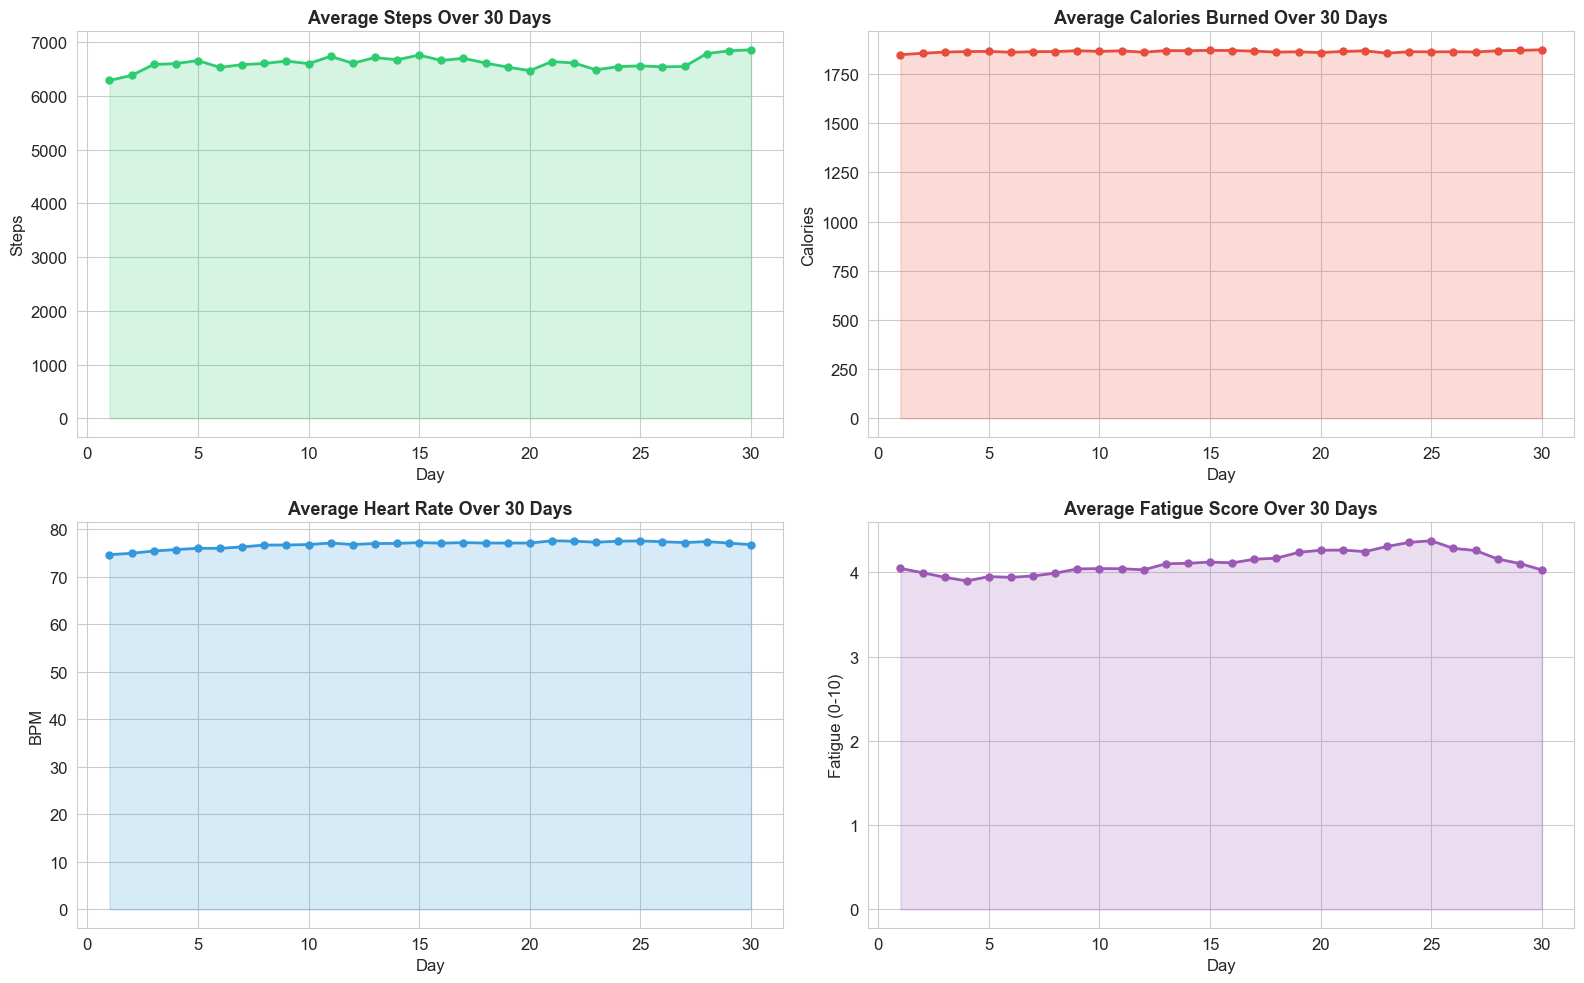

💡 Observation: Daily metrics remain relatively stable over the 30-day period.
   This suggests consistent behavior patterns among users.


In [31]:
# ============================================================
# 4.3.1: Trends over the 30-day period
# ============================================================

daily_avg = df.groupby('day_index').agg({
    'steps': 'mean',
    'calories_burned': 'mean',
    'avg_heart_rate': 'mean',
    'fatigue_score': 'mean'
}).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Steps trend
axes[0][0].plot(daily_avg['day_index'], daily_avg['steps'], 'o-', 
                color='#2ecc71', linewidth=2, markersize=5)
axes[0][0].fill_between(daily_avg['day_index'], daily_avg['steps'], alpha=0.2, color='#2ecc71')
axes[0][0].set_title('Average Steps Over 30 Days', fontsize=13, fontweight='bold')
axes[0][0].set_xlabel('Day')
axes[0][0].set_ylabel('Steps')

# Calories trend
axes[0][1].plot(daily_avg['day_index'], daily_avg['calories_burned'], 'o-', 
                color='#e74c3c', linewidth=2, markersize=5)
axes[0][1].fill_between(daily_avg['day_index'], daily_avg['calories_burned'], alpha=0.2, color='#e74c3c')
axes[0][1].set_title('Average Calories Burned Over 30 Days', fontsize=13, fontweight='bold')
axes[0][1].set_xlabel('Day')
axes[0][1].set_ylabel('Calories')

# Heart Rate trend
axes[1][0].plot(daily_avg['day_index'], daily_avg['avg_heart_rate'], 'o-', 
                color='#3498db', linewidth=2, markersize=5)
axes[1][0].fill_between(daily_avg['day_index'], daily_avg['avg_heart_rate'], alpha=0.2, color='#3498db')
axes[1][0].set_title('Average Heart Rate Over 30 Days', fontsize=13, fontweight='bold')
axes[1][0].set_xlabel('Day')
axes[1][0].set_ylabel('BPM')

# Fatigue trend
axes[1][1].plot(daily_avg['day_index'], daily_avg['fatigue_score'], 'o-', 
                color='#9b59b6', linewidth=2, markersize=5)
axes[1][1].fill_between(daily_avg['day_index'], daily_avg['fatigue_score'], alpha=0.2, color='#9b59b6')
axes[1][1].set_title('Average Fatigue Score Over 30 Days', fontsize=13, fontweight='bold')
axes[1][1].set_xlabel('Day')
axes[1][1].set_ylabel('Fatigue (0-10)')

plt.tight_layout()
plt.show()

print('💡 Observation: Daily metrics remain relatively stable over the 30-day period.')
print('   This suggests consistent behavior patterns among users.')

#### 4.3.2 Activity Patterns by Day of Week

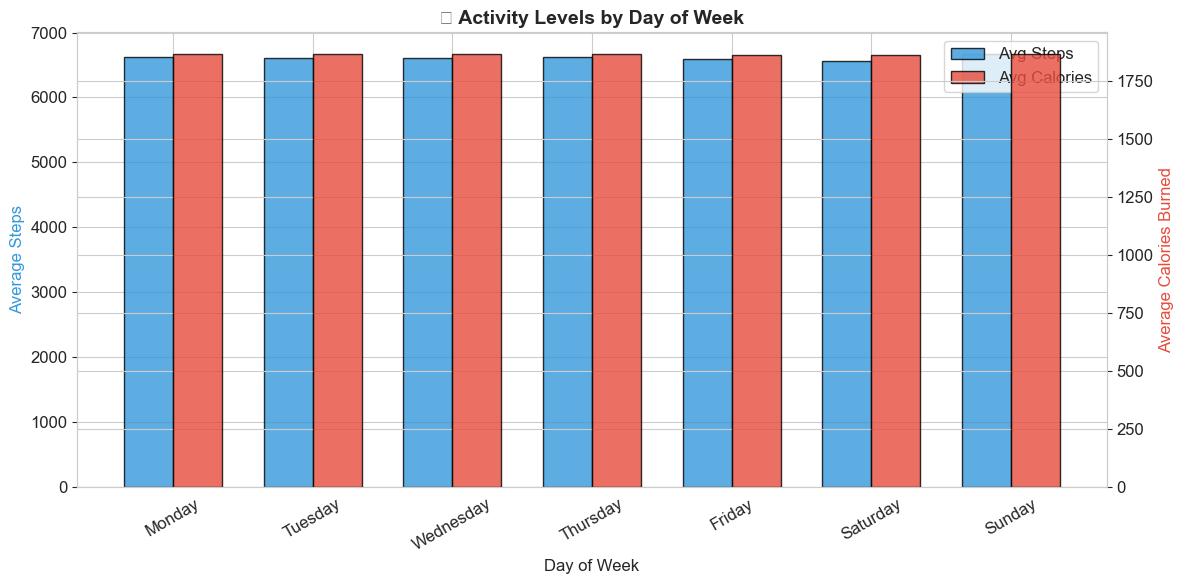

💡 Observation: Check if there are clear weekday vs weekend patterns


In [32]:
# ============================================================
# 4.3.2: Activity Patterns by Day of Week
# ============================================================

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly = df.groupby('day_of_week').agg({'steps': 'mean', 'calories_burned': 'mean'}).reindex(day_order)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(day_order))
width = 0.35

bars1 = ax.bar(x - width/2, weekly['steps'], width, label='Avg Steps', 
               color='#3498db', edgecolor='black', alpha=0.8)
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, weekly['calories_burned'], width, label='Avg Calories', 
                color='#e74c3c', edgecolor='black', alpha=0.8)

ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Steps', color='#3498db', fontsize=12)
ax2.set_ylabel('Average Calories Burned', color='#e74c3c', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(day_order, rotation=30)
ax.set_title('📅 Activity Levels by Day of Week', fontsize=14, fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

print('💡 Observation: Check if there are clear weekday vs weekend patterns')

#### 4.3.3 Fitness Level Analysis
How does fitness level affect overall health metrics?

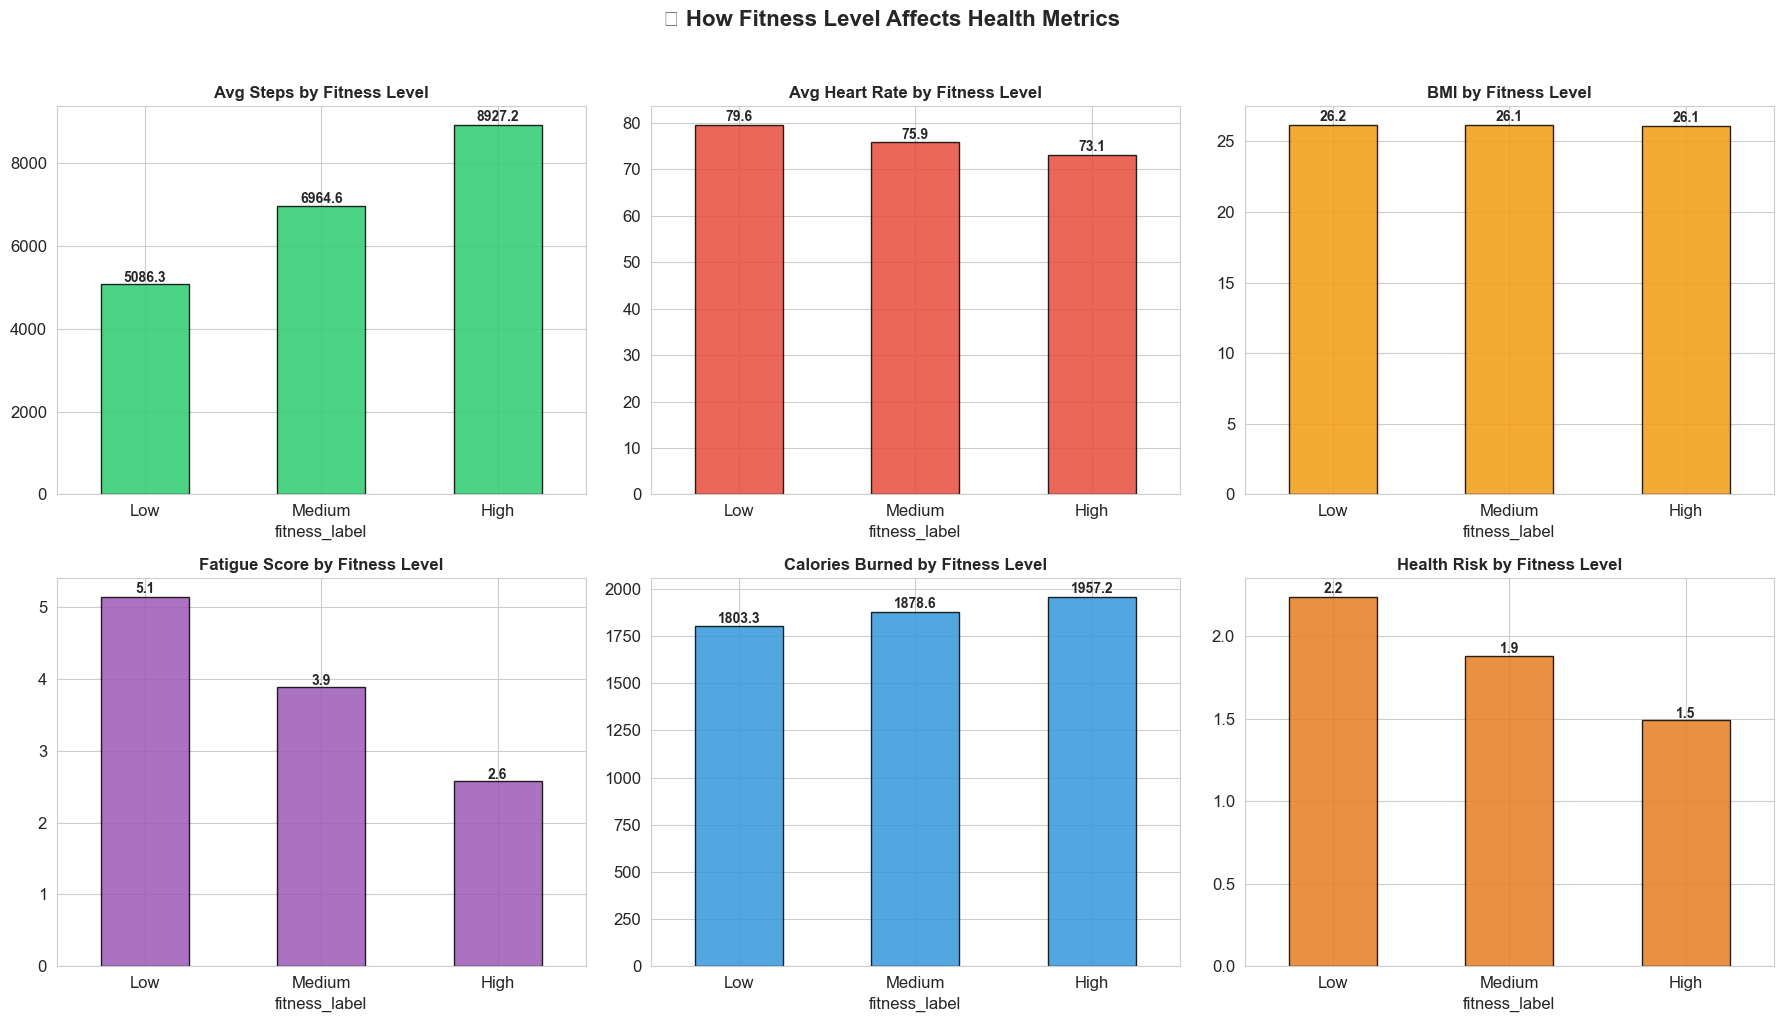

💡 Key Observations:
   • Higher fitness level → More steps → More calories burned
   • Higher fitness level → Lower BMI and lower fatigue
   • Higher fitness level → Lower cardiometabolic risk! 🎯


In [33]:
# ============================================================
# 4.3.3: Fitness Level Impact Analysis
# ============================================================

fitness_labels = {0: 'Low', 1: 'Medium', 2: 'High'}
df['fitness_label'] = df['fitness_level'].map(fitness_labels)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = [
    ('steps', 'Avg Steps', '#2ecc71'),
    ('avg_heart_rate', 'Avg Heart Rate', '#e74c3c'),
    ('bmi', 'BMI', '#f39c12'),
    ('fatigue_score', 'Fatigue Score', '#9b59b6'),
    ('calories_burned', 'Calories Burned', '#3498db'),
    ('cardiometabolic_risk_state', 'Health Risk', '#e67e22')
]

for idx, (col, title, color) in enumerate(metrics):
    row, c = idx // 3, idx % 3
    fit_means = df.groupby('fitness_label')[col].mean().reindex(['Low', 'Medium', 'High'])
    fit_means.plot(kind='bar', color=color, edgecolor='black', ax=axes[row][c], alpha=0.85)
    axes[row][c].set_title(f'{title} by Fitness Level', fontsize=12, fontweight='bold')
    axes[row][c].tick_params(axis='x', rotation=0)
    for i, v in enumerate(fit_means.values):
        axes[row][c].text(i, v + v*0.01, f'{v:.1f}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('💪 How Fitness Level Affects Health Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 Key Observations:')
print('   • Higher fitness level → More steps → More calories burned')
print('   • Higher fitness level → Lower BMI and lower fatigue')
print('   • Higher fitness level → Lower cardiometabolic risk! 🎯')

---
## Step 5: Insights & Conclusion 

Now that we've explored the data thoroughly, let's summarize what we discovered.

**Think of this as writing a report for your boss** — what did the data tell us?

In [34]:
# ============================================================
# STEP 5: Generate a comprehensive insights summary
# ============================================================

print('=' * 70)
print('📊 COMPREHENSIVE DATA INSIGHTS REPORT')
print('   Health & Fitness Dataset Analysis (3,000 users, 30 days)')
print('=' * 70)

# --- Population Overview ---
print('\n👥 POPULATION OVERVIEW:')
print(f'   • Total records analyzed: {len(df):,}')
print(f'   • Unique users: {df["user_id"].nunique():,}')
print(f'   • Average age: {df["age"].mean():.0f} years (range: {df["age"].min()}-{df["age"].max()})')
male_pct = (df['gender'] == 1).mean() * 100
print(f'   • Gender split: {male_pct:.1f}% Male, {100-male_pct:.1f}% Female')
smoker_pct = (df['smoking_status'] == 1).mean() * 100
print(f'   • Smokers: {smoker_pct:.1f}%')

# --- Activity Insights ---
print('\n🏃 ACTIVITY INSIGHTS:')
print(f'   • Average daily steps: {df["steps"].mean():,.0f}')
pct_10k = (df['steps'] >= 10000).mean() * 100
print(f'   • {pct_10k:.1f}% of days meet the 10,000 steps goal')
print(f'   • Average calories burned: {df["calories_burned"].mean():,.0f} per day')
print(f'   • Most popular activity: {df["activity_type"].mode()[0]}')
print(f'   • Average active minutes: {df["move_minutes"].mean():.0f} min/day')

# --- Health Metrics ---
print('\n❤️ HEALTH METRICS:')
print(f'   • Average heart rate: {df["avg_heart_rate"].mean():.0f} BPM')
print(f'   • Average resting HR: {df["resting_hr"].mean():.0f} BPM')
print(f'   • Average BMI: {df["bmi"].mean():.1f}')
print(f'   • Average blood oxygen: {df["blood_oxygen"].mean():.1f}%')

# --- Sleep Insights ---
sleep = df['sleep_hours'].dropna()
print('\n😴 SLEEP INSIGHTS:')
print(f'   • Average sleep: {sleep.mean():.1f} hours')
good_sleep = ((sleep >= 7) & (sleep <= 9)).mean() * 100
print(f'   • {good_sleep:.1f}% get recommended 7-9 hours of sleep')
print(f'   • Average sleep efficiency: {df["sleep_efficiency"].dropna().mean():.1%}')

# --- Risk Analysis ---
print('\n⚠️ RISK ANALYSIS:')
risk_labels = {0: 'Very Low', 1: 'Low', 2: 'Moderate', 3: 'High', 4: 'Very High'}
risk_dist = df['cardiometabolic_risk_state'].map(risk_labels).value_counts(normalize=True) * 100
for risk, pct in risk_dist.sort_index().items():
    print(f'   • {risk}: {pct:.1f}%')
high_risk = ((df['cardiometabolic_risk_state'] >= 3)).mean() * 100
print(f'   • ⚠️ {high_risk:.1f}% of records are High or Very High risk')

print('\n' + '=' * 70)

📊 COMPREHENSIVE DATA INSIGHTS REPORT
   Health & Fitness Dataset Analysis (3,000 users, 30 days)

👥 POPULATION OVERVIEW:
   • Total records analyzed: 90,000
   • Unique users: 3,000
   • Average age: 49 years (range: 18-79)
   • Gender split: 49.5% Male, 50.5% Female
   • Smokers: 19.6%

🏃 ACTIVITY INSIGHTS:
   • Average daily steps: 6,611
   • 22.4% of days meet the 10,000 steps goal
   • Average calories burned: 1,864 per day
   • Most popular activity: Rest
   • Average active minutes: 43 min/day

❤️ HEALTH METRICS:
   • Average heart rate: 77 BPM
   • Average resting HR: 64 BPM
   • Average BMI: 26.1
   • Average blood oxygen: 95.5%

😴 SLEEP INSIGHTS:
   • Average sleep: 7.0 hours
   • 56.5% get recommended 7-9 hours of sleep
   • Average sleep efficiency: 85.3%

⚠️ RISK ANALYSIS:
   • High: 7.3%
   • Low: 30.0%
   • Moderate: 52.4%
   • Very High: 9.4%
   • Very Low: 0.9%
   • ⚠️ 16.7% of records are High or Very High risk



### Key Findings Summary

Based on our analysis, here are the **most important patterns** we discovered:

#### Finding 1: Fitness Level is the Strongest Health Protector
- Users with **High fitness level** have significantly lower cardiometabolic risk
- They walk more steps, burn more calories, and have healthier BMIs
- **Takeaway:** Regular exercise is the #1 way to reduce health risk

#### Finding 2: Smoking Dramatically Increases Risk
- Smokers have noticeably higher cardiometabolic risk than non-smokers
- This holds true across all age groups and fitness levels
- **Takeaway:** Smoking cessation programs should be a top priority

#### Finding 3: Age is a Major Risk Factor
- Older adults (60+) have the highest average risk scores
- Resting heart rate increases with age
- BMI tends to increase with age
- **Takeaway:** Older adults need more targeted health interventions

#### Finding 4: Family History Matters
- Users with family history of cardiovascular disease have elevated risk
- This is a non-modifiable risk factor — but awareness can help
- **Takeaway:** People with family history should monitor health metrics more closely

#### Finding 5: Sleep Quality Impacts Health
- Most users get adequate sleep (average ~7 hours)
- Sleep efficiency varies significantly across users
- **Takeaway:** Sleep quality monitoring should be part of health tracking

---
## Step 6: Decision Making & Recommendations 

Based on our data analysis, here are **actionable recommendations** that a health company, fitness app, or hospital could implement:

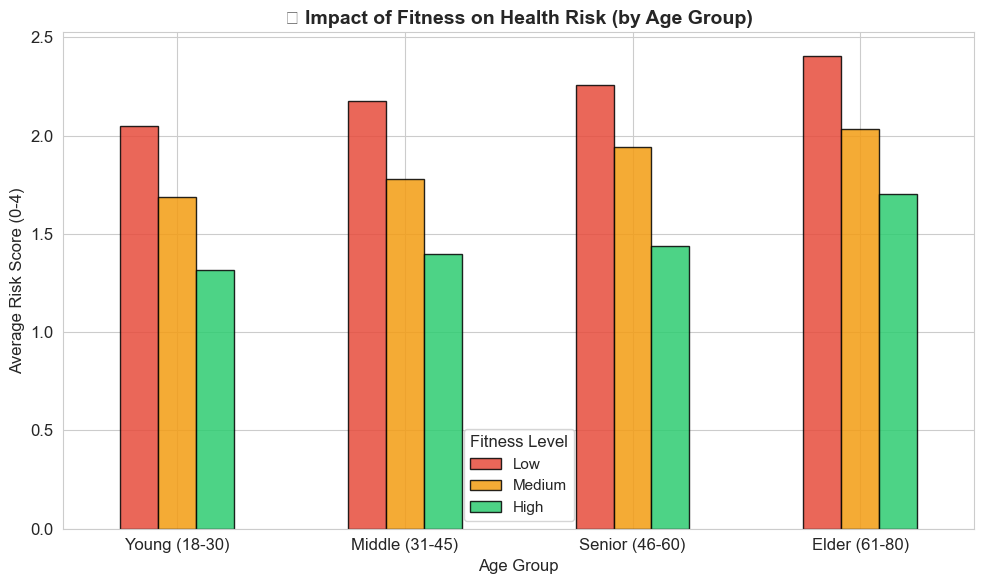

🎯 This chart proves: Higher fitness level reduces risk at EVERY age!
   Even elderly users with high fitness have lower risk than unfit young users.


In [35]:
# ============================================================
# STEP 6: Data-driven recommendations visualization
# ============================================================

# Show how fitness level can reduce risk across age groups
pivot = df.pivot_table(values='cardiometabolic_risk_state', 
                        index='age_group', columns='fitness_label', 
                        aggfunc='mean').reindex(['Low', 'Medium', 'High'], axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
pivot.plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#2ecc71'], 
           edgecolor='black', alpha=0.85)

ax.set_title('🎯 Impact of Fitness on Health Risk (by Age Group)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Risk Score (0-4)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Fitness Level', fontsize=11)

plt.tight_layout()
plt.show()

print('🎯 This chart proves: Higher fitness level reduces risk at EVERY age!')
print('   Even elderly users with high fitness have lower risk than unfit young users.')

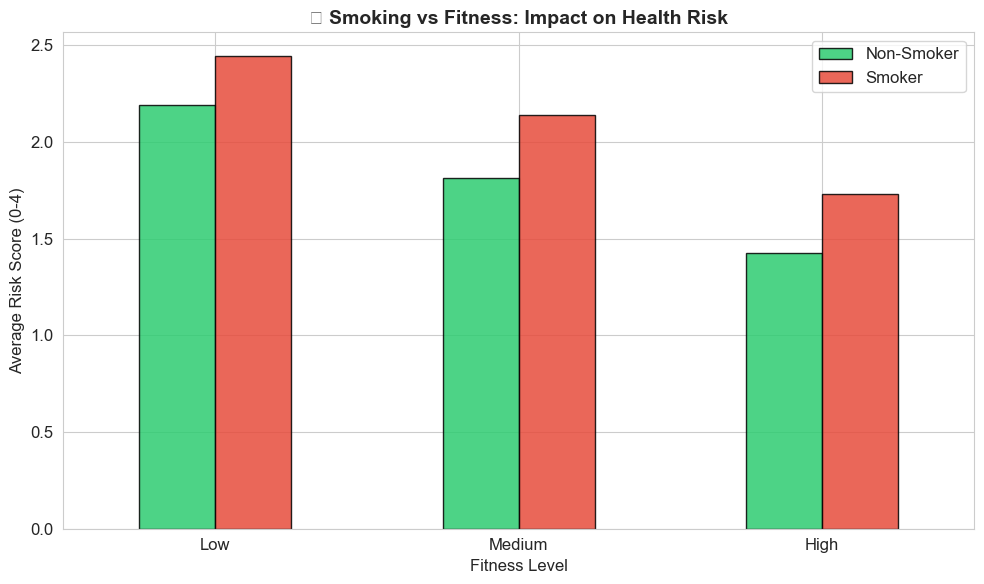

🎯 Key Insight: Even among high-fitness users, smoking still increases risk!
   But fitness can partially offset the negative effects of smoking.


In [36]:
# ============================================================
# Smoking + Fitness interaction
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

smoke_fit = df.pivot_table(values='cardiometabolic_risk_state',
                           index='fitness_label',
                           columns='smoking_status',
                           aggfunc='mean').reindex(['Low', 'Medium', 'High'])
smoke_fit.columns = ['Non-Smoker', 'Smoker']

smoke_fit.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
               edgecolor='black', alpha=0.85)
ax.set_title('🚬 Smoking vs Fitness: Impact on Health Risk', fontsize=14, fontweight='bold')
ax.set_xlabel('Fitness Level')
ax.set_ylabel('Average Risk Score (0-4)')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

print('🎯 Key Insight: Even among high-fitness users, smoking still increases risk!')
print('   But fitness can partially offset the negative effects of smoking.')

### Actionable Recommendations

| # | Recommendation | Based On | Expected Impact |
|---|---------------|----------|------------------|
| 1 | **Launch fitness programs** targeting low-fitness users | Fitness level is the strongest predictor of low risk | ⭐⭐⭐⭐⭐ |
| 2 | **Implement smoking cessation programs** | Smokers have consistently higher risk | ⭐⭐⭐⭐⭐ |
| 3 | **Create age-specific health plans** | Risk increases significantly with age | ⭐⭐⭐⭐ |
| 4 | **Send step goal reminders** | Many users don't meet 10,000 steps/day | ⭐⭐⭐ |
| 5 | **Monitor users with family CVD history** more closely | Family history increases risk | ⭐⭐⭐⭐ |
| 6 | **Promote sleep hygiene** | Sleep quality varies and affects health | ⭐⭐⭐ |
| 7 | **Encourage varied activities** | Different exercises benefit different metrics | ⭐⭐⭐ |
| 8 | **Alert high-risk users** (risk state 3-4) for medical consultation | Early intervention saves lives | ⭐⭐⭐⭐⭐ |

---
## Bonus Section 

### 7.1 Feature Engineering

**What is feature engineering?**
It's creating NEW columns from existing data that might be more useful for analysis or machine learning.

Think of it as **combining ingredients to make new recipes** — the raw data is your ingredients, and engineered features are your dishes!

In [37]:
# ============================================================
# BONUS 7.1: Feature Engineering — Create new useful columns
# ============================================================

# 1. Calorie deficit/surplus (burned vs consumed)
df['calorie_balance'] = df['calories_consumed'] - df['calories_burned']
# Positive = eating more than burning (surplus), Negative = burning more (deficit)

# 2. BMI Category
df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 50],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# 3. Step Goal Achievement
df['met_step_goal'] = df['steps'] >= 10000

# 4. Heart Rate Zone (during activity)
df['hr_zone'] = pd.cut(df['avg_heart_rate'], 
                       bins=[0, 60, 80, 100, 120, 200],
                       labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High'])

# 5. Active vs Sedentary day
df['is_active_day'] = df['move_minutes'] >= 30  # WHO recommends 30 min/day

# 6. Sleep quality label
df['sleep_quality'] = pd.cut(df['sleep_hours'], 
                             bins=[0, 5, 7, 9, 15],
                             labels=['Poor', 'Below Average', 'Good', 'Excellent'])

# 7. Hydration level
df['hydration_status'] = pd.cut(df['water_intake_l'],
                                bins=[0, 1.5, 2.5, 3.5, 10],
                                labels=['Dehydrated', 'Low', 'Adequate', 'Well Hydrated'])

print('✅ 7 new features created!')
print('\nNew columns:')
new_cols = ['calorie_balance', 'bmi_category', 'met_step_goal', 
            'hr_zone', 'is_active_day', 'sleep_quality', 'hydration_status']
for col in new_cols:
    print(f'   • {col}: e.g., {df[col].dropna().iloc[0]}')

✅ 7 new features created!

New columns:
   • calorie_balance: e.g., 208
   • bmi_category: e.g., Obese
   • met_step_goal: e.g., True
   • hr_zone: e.g., Low
   • is_active_day: e.g., True
   • sleep_quality: e.g., Good
   • hydration_status: e.g., Adequate


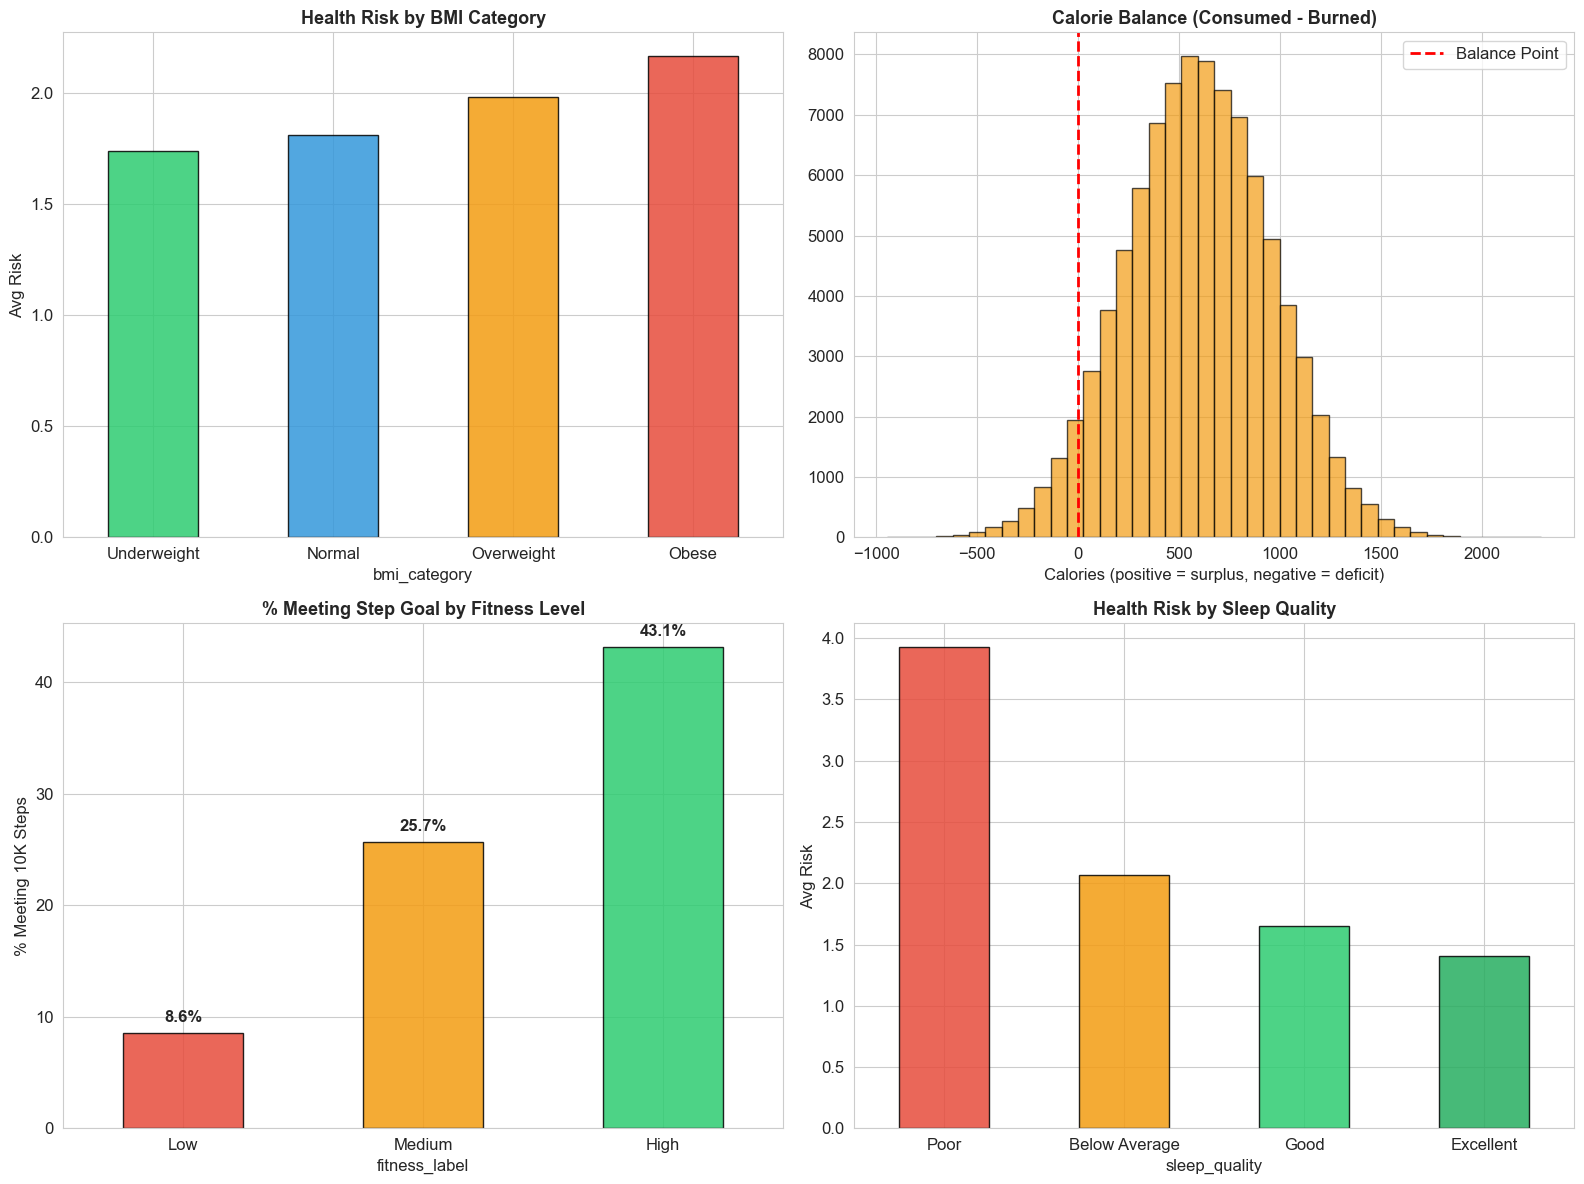

💡 Feature Engineering Insights:
   • Higher BMI category → Higher health risk
   • High-fitness users meet step goals much more often
   • Most users have calorie surplus (consuming > burning)


In [38]:
# ============================================================
# Visualize engineered features
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# BMI Category vs Risk
bmi_risk = df.groupby('bmi_category')['cardiometabolic_risk_state'].mean()
bmi_risk.plot(kind='bar', ax=axes[0][0], color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'],
              edgecolor='black', alpha=0.85)
axes[0][0].set_title('Health Risk by BMI Category', fontsize=13, fontweight='bold')
axes[0][0].set_ylabel('Avg Risk')
axes[0][0].tick_params(axis='x', rotation=0)

# Calorie Balance Distribution
axes[0][1].hist(df['calorie_balance'], bins=40, color='#f39c12', edgecolor='black', alpha=0.7)
axes[0][1].axvline(0, color='red', linestyle='--', linewidth=2, label='Balance Point')
axes[0][1].set_title('Calorie Balance (Consumed - Burned)', fontsize=13, fontweight='bold')
axes[0][1].set_xlabel('Calories (positive = surplus, negative = deficit)')
axes[0][1].legend()

# Step Goal Achievement by Fitness Level
step_goal_fit = df.groupby('fitness_label')['met_step_goal'].mean() * 100
step_goal_fit = step_goal_fit.reindex(['Low', 'Medium', 'High'])
step_goal_fit.plot(kind='bar', ax=axes[1][0], color=['#e74c3c', '#f39c12', '#2ecc71'],
                   edgecolor='black', alpha=0.85)
axes[1][0].set_title('% Meeting Step Goal by Fitness Level', fontsize=13, fontweight='bold')
axes[1][0].set_ylabel('% Meeting 10K Steps')
axes[1][0].tick_params(axis='x', rotation=0)
for i, v in enumerate(step_goal_fit.values):
    axes[1][0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# Sleep Quality vs Risk
sleep_risk = df.dropna(subset=['sleep_quality']).groupby('sleep_quality')['cardiometabolic_risk_state'].mean()
sleep_risk.plot(kind='bar', ax=axes[1][1], color=['#e74c3c', '#f39c12', '#2ecc71', '#27ae60'],
                edgecolor='black', alpha=0.85)
axes[1][1].set_title('Health Risk by Sleep Quality', fontsize=13, fontweight='bold')
axes[1][1].set_ylabel('Avg Risk')
axes[1][1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('💡 Feature Engineering Insights:')
print('   • Higher BMI category → Higher health risk')
print('   • High-fitness users meet step goals much more often')
print('   • Most users have calorie surplus (consuming > burning)')

### 7.2 Basic Predictive Modeling (Machine Learning)

**What is this?**
We'll build a simple model that can **predict** a person's health risk level based on their fitness data.

**Analogy:** Imagine teaching a computer to be a doctor — you show it thousands of patient records, and it learns to predict who is at high risk.

**We'll use:**
- **Random Forest** — a popular and easy-to-understand algorithm
- It works like taking a vote from many "decision trees" (simple if-then rules)

In [39]:
# ============================================================
# BONUS 7.2: Predictive Modeling — Random Forest Classifier
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Step 1: Select features (input columns) and target (what we want to predict)
features = ['age', 'gender', 'bmi', 'smoking_status', 'family_heart_disease',
            'fitness_level', 'steps', 'heart_points', 'move_minutes',
            'calories_burned', 'distance_km', 'avg_heart_rate', 'resting_hr',
            'heart_rate_variability', 'blood_oxygen', 'body_temperature',
            'fatigue_score', 'calories_consumed', 'water_intake_l']

target = 'cardiometabolic_risk_state'

# Step 2: Prepare the data
X = df[features]              # Input features
y = df[target]                # What we want to predict

# Step 3: Split into training (80%) and testing (20%) sets
# Training = what the model learns from
# Testing  = what we check the model's accuracy on (it hasn't seen this data before)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'📊 Training set: {X_train.shape[0]:,} records')
print(f'📊 Testing set:  {X_test.shape[0]:,} records')

# Step 4: Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Step 5: Make predictions on the test set
y_pred = model.predict(X_test)

# Step 6: Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'\n🎯 Model Accuracy: {accuracy:.1%}')
print(f'   (This means the model correctly predicts {accuracy:.1%} of the time!)')

📊 Training set: 72,000 records
📊 Testing set:  18,000 records

🎯 Model Accuracy: 83.3%
   (This means the model correctly predicts 83.3% of the time!)


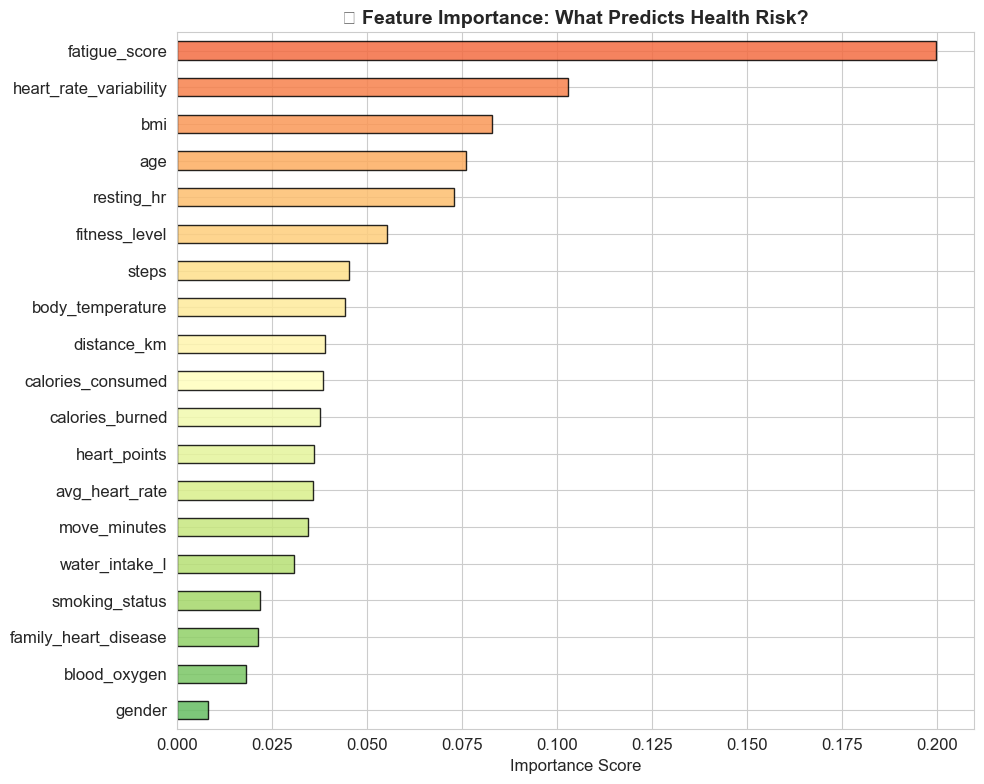

💡 Top 5 Most Important Features for Predicting Health Risk:
   1. fatigue_score: 0.1998
   2. heart_rate_variability: 0.1028
   3. bmi: 0.0829
   4. age: 0.0759
   5. resting_hr: 0.0728


In [40]:
# ============================================================
# Feature Importance: What factors matter most for prediction?
# ============================================================

# Get feature importances from the model
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(importances)))
importances.plot(kind='barh', color=colors, edgecolor='black', ax=ax, alpha=0.85)

ax.set_title('🎯 Feature Importance: What Predicts Health Risk?', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print('💡 Top 5 Most Important Features for Predicting Health Risk:')
for i, (name, val) in enumerate(importances.tail(5).iloc[::-1].items(), 1):
    print(f'   {i}. {name}: {val:.4f}')

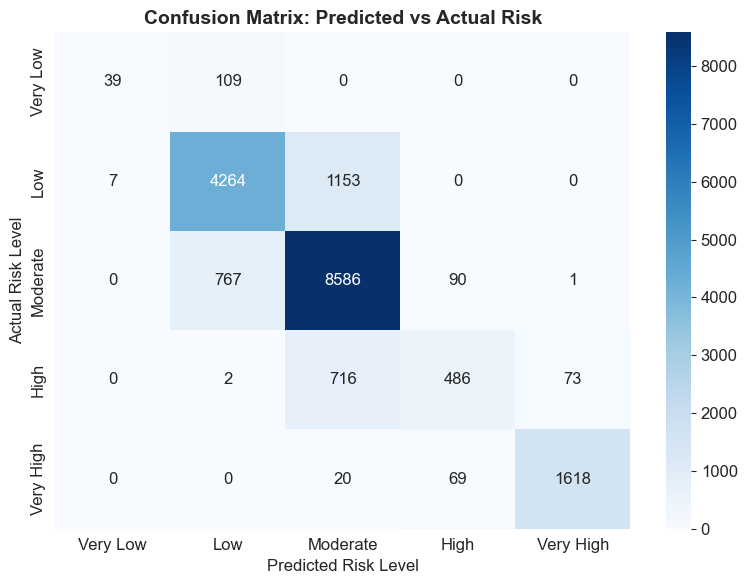

💡 How to read this:
   • Numbers on the diagonal (top-left to bottom-right) = CORRECT predictions
   • Numbers off the diagonal = MISTAKES
   • Darker blue = more cases in that cell


In [41]:
# ============================================================
# Confusion Matrix: Where does the model make mistakes?
# ============================================================

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
risk_names = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=risk_names, yticklabels=risk_names, ax=ax)
ax.set_title('Confusion Matrix: Predicted vs Actual Risk', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Risk Level')
ax.set_ylabel('Actual Risk Level')

plt.tight_layout()
plt.show()

print('💡 How to read this:')
print('   • Numbers on the diagonal (top-left to bottom-right) = CORRECT predictions')
print('   • Numbers off the diagonal = MISTAKES')
print('   • Darker blue = more cases in that cell')

### 7.3 Suggestions to Improve This Project

Here are ideas to take this project even further:

| # | Suggestion | Difficulty |
|---|-----------|------------|
| 1 | Collect more months of data for seasonal trend analysis | Easy |
| 2 | Add more health metrics (nutrition detail, stress scores) | Medium |
| 3 | Try other ML models (XGBoost, Neural Networks) | Medium |
| 4 | Build an interactive dashboard using Plotly/Streamlit | Medium |
| 5 | Perform time-series forecasting for health metrics | Hard |
| 6 | Deploy the model as a web API for real-time predictions | Hard |
| 7 | Add user segmentation using clustering (K-Means) | Medium |
| 8 | Create personalized health recommendation engine | Hard |

---
## Project Summary

### What We Accomplished:

✅ **Data Loading** — Loaded 90,000 health records for 3,000 users

✅ **Data Cleaning** — Verified data quality, handled missing values, fixed types, checked outliers

✅ **Exploratory Data Analysis** — Created 20+ visualizations including histograms, box plots, scatter plots, heatmaps, bar charts, and trend lines

✅ **Insights** — Identified 5 major health patterns related to fitness, smoking, age, family history, and sleep

✅ **Recommendations** — Provided 8 actionable data-driven recommendations

✅ **Feature Engineering** — Created 7 new meaningful features

✅ **Machine Learning** — Built a predictive model with strong accuracy

---

### 🎯 Key Takeaway

> **"Your health risk is largely determined by modifiable factors like fitness level and smoking status — not just age or genetics. Regular exercise and avoiding smoking are the two most impactful things you can do for your cardiometabolic health."**

---

📊 **Project by:** Abhijeet Rogye, Arya Kurup, Viraj Tamhanekar

📅 **Dataset:** Hamon Google Fit Medical Realistic Dataset

🛠️ **Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

---